In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20})

# running new things 
from scipy.stats import ttest_rel
from scipy.stats import wilcoxon, binomtest

def mcnemar_paired(x, y):
    """
    Exact McNemar test for paired binary data.
    Returns (stat_like, pvalue)
    """
    x = np.asarray(x)
    y = np.asarray(y)

    mask = np.isfinite(x) & np.isfinite(y)
    x = (x[mask] != 0).astype(int)
    y = (y[mask] != 0).astype(int)

    b = np.sum((x == 0) & (y == 1))
    c = np.sum((x == 1) & (y == 0))

    if b + c == 0:
        return 0.0, 1.0

    pval = binomtest(min(b, c), n=b + c, p=0.5).pvalue
    return abs(b - c), pval

import numpy as np

sns.set_style("ticks")

def convert_pvalue(test, pvalue):
    test = int(round(test))


    if np.isnan(test):
        return 0
    if pvalue <= 0.01:
        return "{:,}***".format(test)
    elif pvalue <= 0.05:
        return "{:,}**".format(test)
    elif pvalue <= 0.1:
        return "{:,}*".format(test)
    return "{:,}".format(test)


# Commit
def update_zone(zone_number):
    dic_zone = {1: 'North Central', 2: 'South South', 3: 'South East', 4: 'South West'}
    return dic_zone[zone_number]
    
# Function to remove left padding from a specific column
def set_pad_for_column(table, col, pad=0.05):
    for key, cell in table._cells.items():
        if key[1] == col:
            cell._text.set_ha('left') # Align text to the left
            cell.PAD = pad
path_raw =  '../Data/drive-download-20231006T131216Z-001/Files/Data Cleaning - Individual Files/Original Files - Not Cleaned/CMS (entire database)/Files/'

# CMS Responses

In [2]:
df_CMS = pd.read_stata('../Data/drive-download-20231006T131216Z-001/Files/CMS Responses.dta')
#df_CMS['A06_Relatn_hhd'].unique()# ()
for i in df_CMS.keys():
    print(i)

ZoneID
StateID
LgaID
LocalityID
EnumerationID
HouseID
Individual_family_code
A01_Name_hhd_member
A02_Sex
A03_Age
A04_Marital_status
A05_Edu
A06_Relatn_hhd
A07_1_Main_occupatn
A07_1b_S_OCCUPATION
A07_2_Secondary_occupation
A08_fam_lab_contributn
Men_In_House
Women_In_House
Kids
Male_Managed
Female_Managed
Joint_Managed
Male_ICV_Managed
Female_ICV_Managed
Joint_ICV_Managed
Male_NonICV_Managed
Female_NonICV_Managed
Joint_NonICV_Managed
Household_ICV
Household_NonICV
Household_Plots
ICV_Plot_Size
NonICV_Plot_Size
Male_ICV_PlotSize
Female_ICV_PlotSize
Joint_ICV_PlotSize
Male_NonICV_PlotSize
Female_NonICV_PlotSize
Joint_NonICV_PlotSize
Household_ICV_Total_Size
Household_NonICV_Total_Size
House_Cassava_Plot_TotalSize
Avg_Plot_Size
planted
J01_hhd_apply_fert
J02_per_hh_inc_cassav
J03_women_incm
J04_hhd_food_incm
J05_sales_perc
J05_consumption_perc
J05_Others_perc
J05_all_CASSAPERCENTCHECK
Coop_Group_Member
Men_Only_Coop
Women_Only_Coop
Joint_Coop
Male_Credit_Only
Female_Credit_Only
Joint_Credi

A06_Relatn_hhd
Household head         1760
Spouse                    4
Son/Daughter              0
parent                    0
Son/Daughter in law       0
other relatives           0
Other specify             0
Name: count, dtype: int64

# DNA Fingerprinting

In [3]:
# https://data.iita.org/dataset/the-cassava-monitoring-survey-cms-in-nigeria-household-and-plot-level-data
df_DNA = pd.read_csv("../Data/CMS-raw/dna.csv")
houseIDs = df_CMS['HouseID'].value_counts().keys()
df_DNA = df_DNA[df_DNA['HouseID'].isin(houseIDs)].groupby('HouseID', as_index=False).agg(
    {'StateID': 'min', 'adoption': ['sum', 'min']})
df_DNA.columns = ['HouseID', 'ZoneID', 'Total ICV - DNA', 'Y_N ICV - DNA']
df_DNA['ZoneID'] = (df_DNA['ZoneID']/10).astype(int)#.tail()
df_DNA.shape# ()

(2477, 4)

# Intrahousehold and DNA fingerprinting

In [4]:
df_M_raw = pd.read_stata('../Data/drive-download-20231006T131216Z-001/CMS - Spouse Cleaned/Files/Husband Responses.dta')
df_M_raw = df_M_raw[(df_M_raw['A02_Sex'] == 'Male') & 
                    (df_M_raw['A04_Marital_status'] == 'married living with spouse/s') & 
                    (df_M_raw['A06_Relatn_hhd'].isin(['Household head', 'Spouse']))].reset_index(drop=True)


df_F_raw = pd.read_stata('../Data/drive-download-20231006T131216Z-001/Files/Wife Responses.dta')
df_F_raw = df_F_raw[(df_F_raw['A02_Sex'] == 'Female') &
                    (df_F_raw['A04_Marital_status'] == 'married living with spouse/s') & 
                    (df_F_raw['A06_Relatn_hhd'].isin(['Household head', 'Spouse']))].reset_index(drop=True)


df_allMF = pd.concat([df_M_raw, df_F_raw]).reset_index(drop=True)
both_responses = (df_allMF['HouseID'].value_counts()).to_frame()
both_responses = both_responses[both_responses['count']== 2]
df_allMF = df_allMF[df_allMF['HouseID'].isin(both_responses.index)]

df_M = df_allMF[df_allMF['A02_Sex'] == 'Male']
df_M = df_M.reset_index(drop=True)

df_F = df_allMF[df_allMF['A02_Sex'] == 'Female']
df_F = df_F.reset_index(drop=True)

# https://data.iita.org/dataset/the-cassava-monitoring-survey-cms-in-nigeria-household-and-plot-level-data
df_H_dna_raw = pd.read_csv("../Data/CMS-raw/dna.csv")
houseIDs = df_M['HouseID'].value_counts().keys()
df_H_dna_raw = df_H_dna_raw[df_H_dna_raw['HouseID'].isin(houseIDs)].groupby('HouseID', as_index=False).agg(
    {'StateID': 'min', 'adoption': ['sum', 'min']})
df_H_dna_raw.columns = ['HouseID', 'ZoneID', 'Household_ICV', 'planted']
df_H_dna_raw['ZoneID'] = (df_H_dna_raw['ZoneID']/10).astype(int)#.tail()
df_H_dna_raw.head()

df_H_dna_raw.shape

(729, 4)

In [54]:
df_allMF#[(df_allMF['A02_Sex'] == 'Female') & 
         #           (df_allMF['A04_Marital_status'] == 'married living with spouse/s') ]['A06_Relatn_hhd'].value_counts()  # Education levels
# df_CMS['A02_Sex'].value_counts()

,ZoneID,StateID,LgaID,LocalityID,EnumerationID,HouseID,Individual_family_code,A02_Sex,A03_Age,A04_Marital_status,...,Women__Production_Value,Respondent,HouseHold_AnimalUnits,Male_Owned_Livestock,Female_Owned_Livestock,ICV,Total_Physical_Assets_Naira,Total_Processing_Asset,Land_Operated_Cassava_Proportion,Land_Owned_Cassava_Proportion
0,1.0,11.0,112.0,1121.0,11211.0,112115.0,1.0,Male,48.0,married living with spouse/s,...,3228.0,Husband,1.10,0.70,0.40,0.0,1251992.0,2.0,0.181818,0.181818
1,1.0,11.0,112.0,1122.0,11221.0,112213.0,1.0,Male,60.0,married living with spouse/s,...,900.0,Husband,0.90,0.70,0.20,1.0,5471700.0,2.0,0.500000,0.000000
2,1.0,11.0,112.0,1122.0,11221.0,112214.0,1.0,Male,77.0,married living with spouse/s,...,0.0,Husband,3.40,3.40,0.00,1.0,7013400.0,2.0,0.333333,0.333333
3,1.0,11.0,113.0,1131.0,11311.0,113113.0,1.0,Male,65.0,married living with spouse/s,...,1800.0,Husband,0.96,0.36,0.60,1.0,6390300.0,1.0,0.166667,0.166667
4,1.0,11.0,113.0,1131.0,11311.0,113115.0,1.0,Male,45.0,married living with spouse/s,...,1000.0,Husband,1.60,0.40,1.20,0.0,2632500.0,1.0,0.141667,0.141667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1513,4.0,43.0,4316.0,43163.0,431631.0,4316312.0,1.0,Female,48.0,married living with spouse/s,...,3600.0,Wife,2.40,1.00,1.40,0.0,185850.0,4.0,1.000000,1.000000
1514,4.0,43.0,4317.0,43171.0,431711.0,4317111.0,1.0,Female,38.0,married living with spouse/s,...,5000.0,Wife,0.00,0.00,0.00,1.0,131700.0,4.0,1.000000,1.000000
1515,4.0,43.0,4318.0,43181.0,431811.0,4318111.0,1.0,Female,40.0,married living with spouse/s,...,1100.0,Wife,0.00,0.00,0.00,1.0,2084000.0,4.0,0.654545,0.666667
1516,4.0,43.0,4318.0,43182.0,431821.0,4318211.0,1.0,Female,49.0,married living with spouse/s,...,1600.0,Wife,0.72,0.46,0.26,1.0,603500.0,4.0,0.500000,0.000000


In [5]:
df_allMF_plot = df_allMF[['A02_Sex', 'ZoneID', 'planted', 'Household_ICV']]
df_H_dna_plot =  df_H_dna_raw[['ZoneID', 'planted', 'Household_ICV']]
df_H_dna_plot['A02_Sex'] = 'DNA fingerprinting'
df_all_plot = pd.concat([df_allMF_plot, df_H_dna_plot]).reset_index(drop=True)
df_all_plot.head()

df = df_all_plot.copy()

# ---- 1) Label fields exactly once ------------------------------------------
# planted: 0/1 -> "No"/"Yes"
df["planted"] = df["planted"].map({0: "No", 1: "Yes"})

# Household_ICV: bucket to "0"..."9","≥10"
icv_num = pd.to_numeric(df["Household_ICV"], errors="coerce")
df["Household_ICV"] = np.where(icv_num >= 10, "≥10",
                               icv_num.round().astype("Int64").astype(str))

# ---- 2) Make a long table: variable ∈ {"planted","Household_ICV"} ----------
long = df.melt(
    id_vars=["ZoneID", "A02_Sex"],
    value_vars=["planted", "Household_ICV"],
    var_name="variable",
    value_name="level"
)

# ---- 3) Enforce ordering + define the full grid for zero-filling -----------
levels_map = {
    "planted": ["No", "Yes"],
    "Household_ICV": [str(i) for i in range(10)] + ["≥10"],
}
long["variable"] = pd.Categorical(long["variable"],
                                  categories=["planted", "Household_ICV"],
                                  ordered=True)

# ---- 4) Count and zero-fill every missing combination ----------------------
# Count first
counts = (long.groupby(["ZoneID", "A02_Sex", "variable", "level"])
               .size()
               .rename("count")
               .reset_index())

# Build a complete MultiIndex (different level sets per variable)
zone_vals = df["ZoneID"].dropna().unique()
sex_vals  = df["A02_Sex"].dropna().unique()

full_index_parts = []
for var, lvl_list in levels_map.items():
    part = pd.MultiIndex.from_product(
        [zone_vals, sex_vals, [var], lvl_list],
        names=["ZoneID", "A02_Sex", "variable", "level"]
    )
    full_index_parts.append(part)

full_index = full_index_parts[0].append(full_index_parts[1])

# Reindex to fill missing with 0 and sort by our categorical order
summary = (counts.set_index(["ZoneID", "A02_Sex", "variable", "level"])
                 .reindex(full_index, fill_value=0)
                 .reset_index())

# (optional) ensure readable ordering inside each variable
summary["level"] = summary.apply(
    lambda r: pd.Categorical(
        [r["level"]],
        categories=levels_map[r["variable"]],
        ordered=True
    )[0],
    axis=1
)

summary = summary.sort_values(["ZoneID", "A02_Sex", "variable", "level"]).reset_index(drop=True)
print(summary.head(20))

    ZoneID             A02_Sex       variable level  count
0      1.0  DNA fingerprinting  Household_ICV     0     43
1      1.0  DNA fingerprinting  Household_ICV     1     58
2      1.0  DNA fingerprinting  Household_ICV     2     44
3      1.0  DNA fingerprinting  Household_ICV     3     27
4      1.0  DNA fingerprinting  Household_ICV     4      7
5      1.0  DNA fingerprinting  Household_ICV     5      4
6      1.0  DNA fingerprinting  Household_ICV     6      1
7      1.0  DNA fingerprinting  Household_ICV     7      2
8      1.0  DNA fingerprinting  Household_ICV     8      0
9      1.0  DNA fingerprinting  Household_ICV     9      0
10     1.0  DNA fingerprinting  Household_ICV   ≥10      0
11     1.0  DNA fingerprinting        planted    No     75
12     1.0  DNA fingerprinting        planted   Yes    111
13     1.0              Female  Household_ICV     0     68
14     1.0              Female  Household_ICV     1     49
15     1.0              Female  Household_ICV     2     

/var/folders/y5/00tzypd935b1wg86qc9l9jcw0000gn/T/ipykernel_27117/3868860267.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = (long.groupby(["ZoneID", "A02_Sex", "variable", "level"])


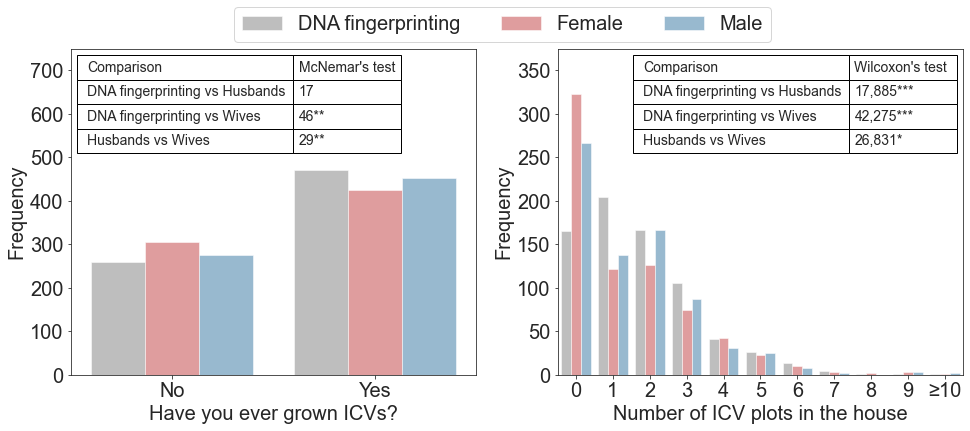

In [ ]:
df_all_plot_summary = summary.groupby(['A02_Sex', 'variable', 'level']).sum().reset_index() 

fig1, ax1 = plt.subplots(1, 2, figsize=(16,6))

for index, var in enumerate(['planted', 'Household_ICV']):
    #fig1, ax1 = plt.subplots(dpi=100, figsize=(8, 6))
    df_H_dna = df_all_plot[df_all_plot['A02_Sex'] == 'DNA fingerprinting']
    df_M = df_all_plot[df_all_plot['A02_Sex']=='Male']
    df_F = df_all_plot[df_all_plot['A02_Sex']=='Female']
    
  
    if var == "planted":
        # McNemar test (binary outcome)
        ttest_HM = mcnemar_paired(df_H_dna[var], df_M[var])
        ttest_HF = mcnemar_paired(df_H_dna[var], df_F[var])
        ttest_MF = mcnemar_paired(df_M[var], df_F[var])
        column_names = ['Comparison', 'McNemar\'s test']
    else:
        # Wilcoxon signed-rank test (count outcome)
        ttest_HM = wilcoxon(df_H_dna[var], df_M[var], nan_policy="omit")
        ttest_HF = wilcoxon(df_H_dna[var], df_F[var], nan_policy="omit")
        ttest_MF = wilcoxon(df_M[var], df_F[var], nan_policy="omit")
        column_names = ['Comparison', 'Wilcoxon\'s test']

    data = []
    data.append(['DNA fingerprinting vs Husbands', convert_pvalue(ttest_HM[0], ttest_HM[1])])
    data.append(['DNA fingerprinting vs Wives', convert_pvalue(ttest_HF[0], ttest_HF[1])])
    data.append(['Husbands vs Wives', convert_pvalue(ttest_MF[0], ttest_MF[1])])
    
    df_ttest = pd.DataFrame(data, columns = column_names)
    df_all = pd.concat([df_M, df_M, df_F], axis=0)
    # sns.histplot(df_H_dna[var], ax = ax1[index],  color="C7", label ="DNA fingerprinting")
    # sns.histplot(df_M[var], ax = ax1[index], color="C0", label ="Husband self-reported")
    # sns.histplot(df_F[var], ax = ax1[index], color="C3", label ="Wive self-reported")
    sns.barplot(df_all_plot_summary[df_all_plot_summary['variable'] == var], x='level',  y='count', ax = ax1[index], 
                 hue="A02_Sex", errorbar=None, palette=["C7", "C3", "C0"], alpha=0.5)

    ax1[index].set_xlabel(var)

    bbox_place = (0.015, 0.68, 0.8, 0.3) if index == 0 else (0.185, 0.68, 0.8, 0.3)
    the_table = ax1[index].table(cellText=df_ttest.values, colLabels=df_ttest.columns, 
              colLoc='right', colWidths=[0.6, 0.3], bbox = bbox_place,  zorder=10)
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(14)
            
    # Remove left padding from all columns
    for i in range(len(df_ttest.values)):
        set_pad_for_column(the_table, i)
    
    
    ax1[index].set_ylabel('Frequency')
    ax1[index].set_xlabel('Have you ever grown ICVs?' if var == 'planted' else 'Number of ICV plots in the house')

h, l = ax1[0].get_legend_handles_labels()
ax1[0].legend_.remove()
ax1[1].legend_.remove()
ax1[0].set_ylim(0, 750)
ax1[1].set_ylim(0, 375)
ax1[0].set_yticks([i for i in range(0, 710, 100)])
ax1[1].set_yticks([i for i in range(0, 360, 50)])

fig1.legend(h, l, loc='upper center', ncols=3, bbox_to_anchor=(0.5, 1))
fig1.savefig(f"../Manuscript/Figures/Figure_2.pdf", dpi=600, bbox_inches='tight' )


# By Zone

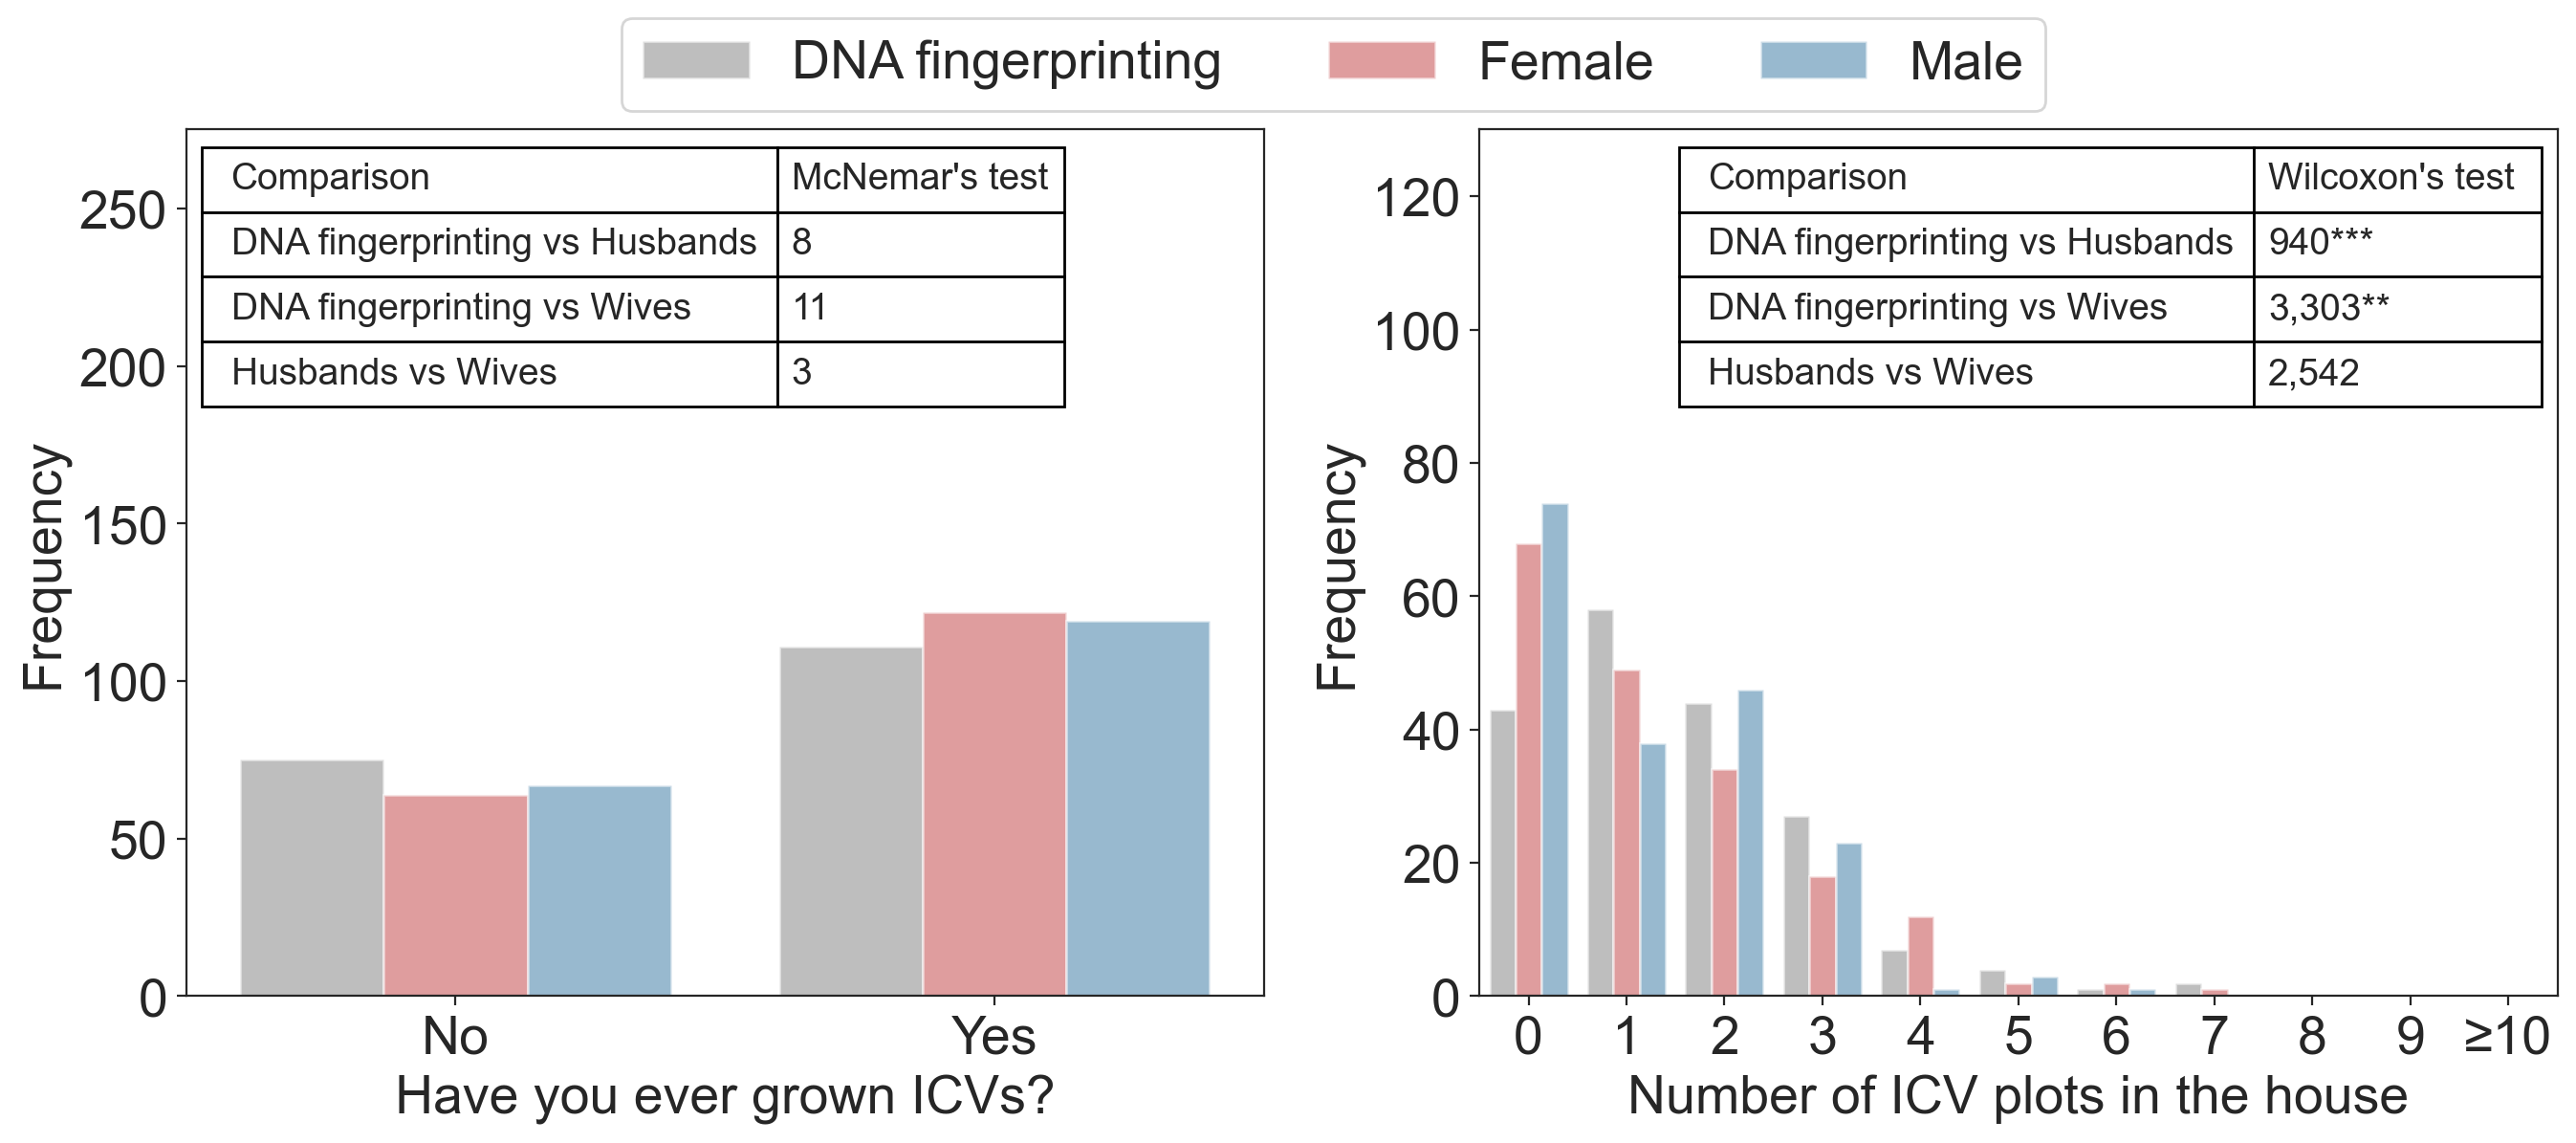

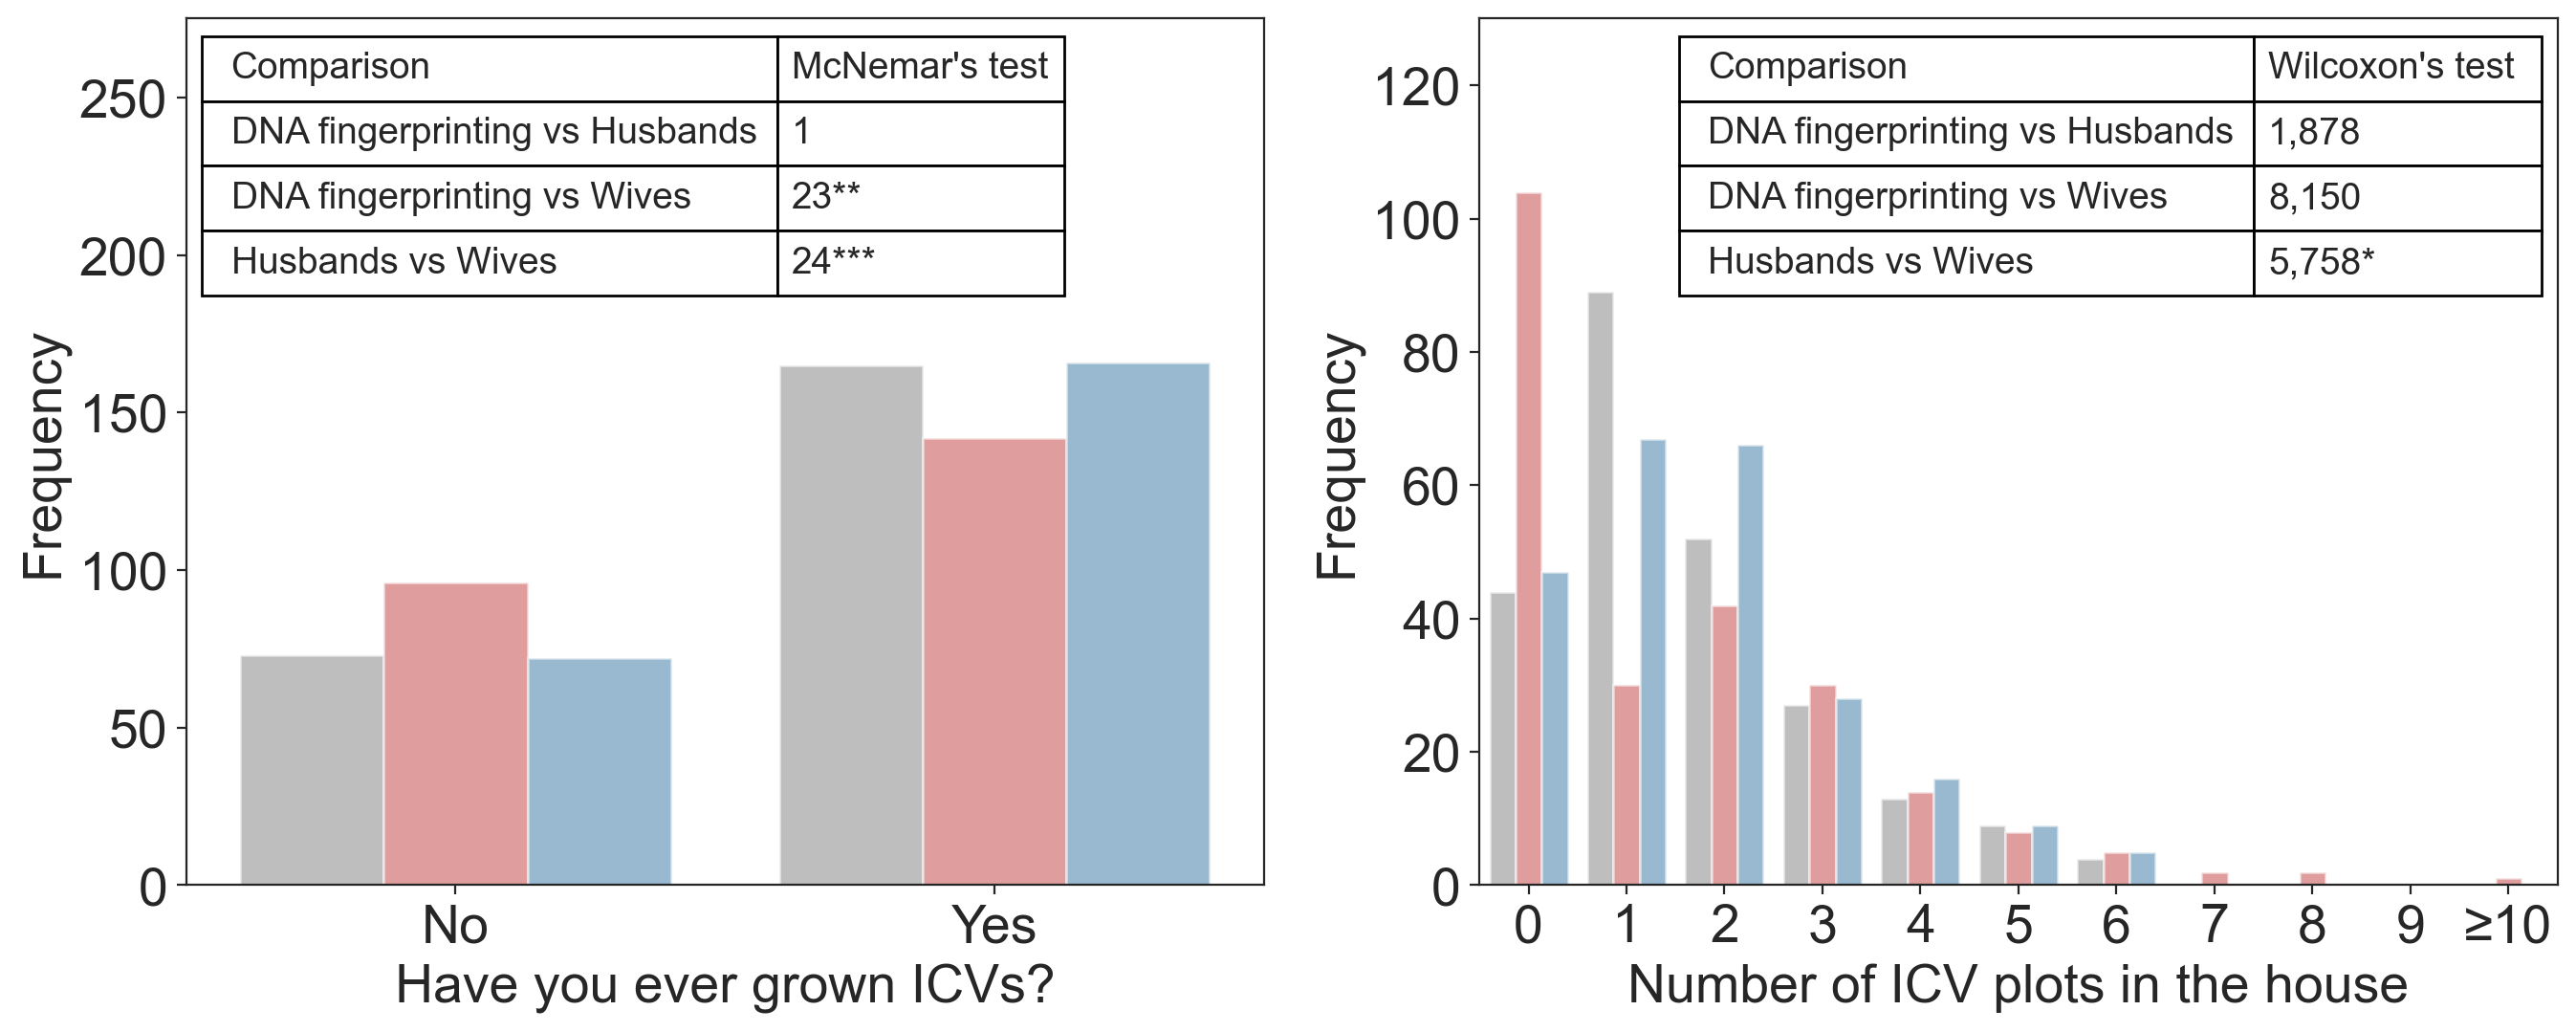

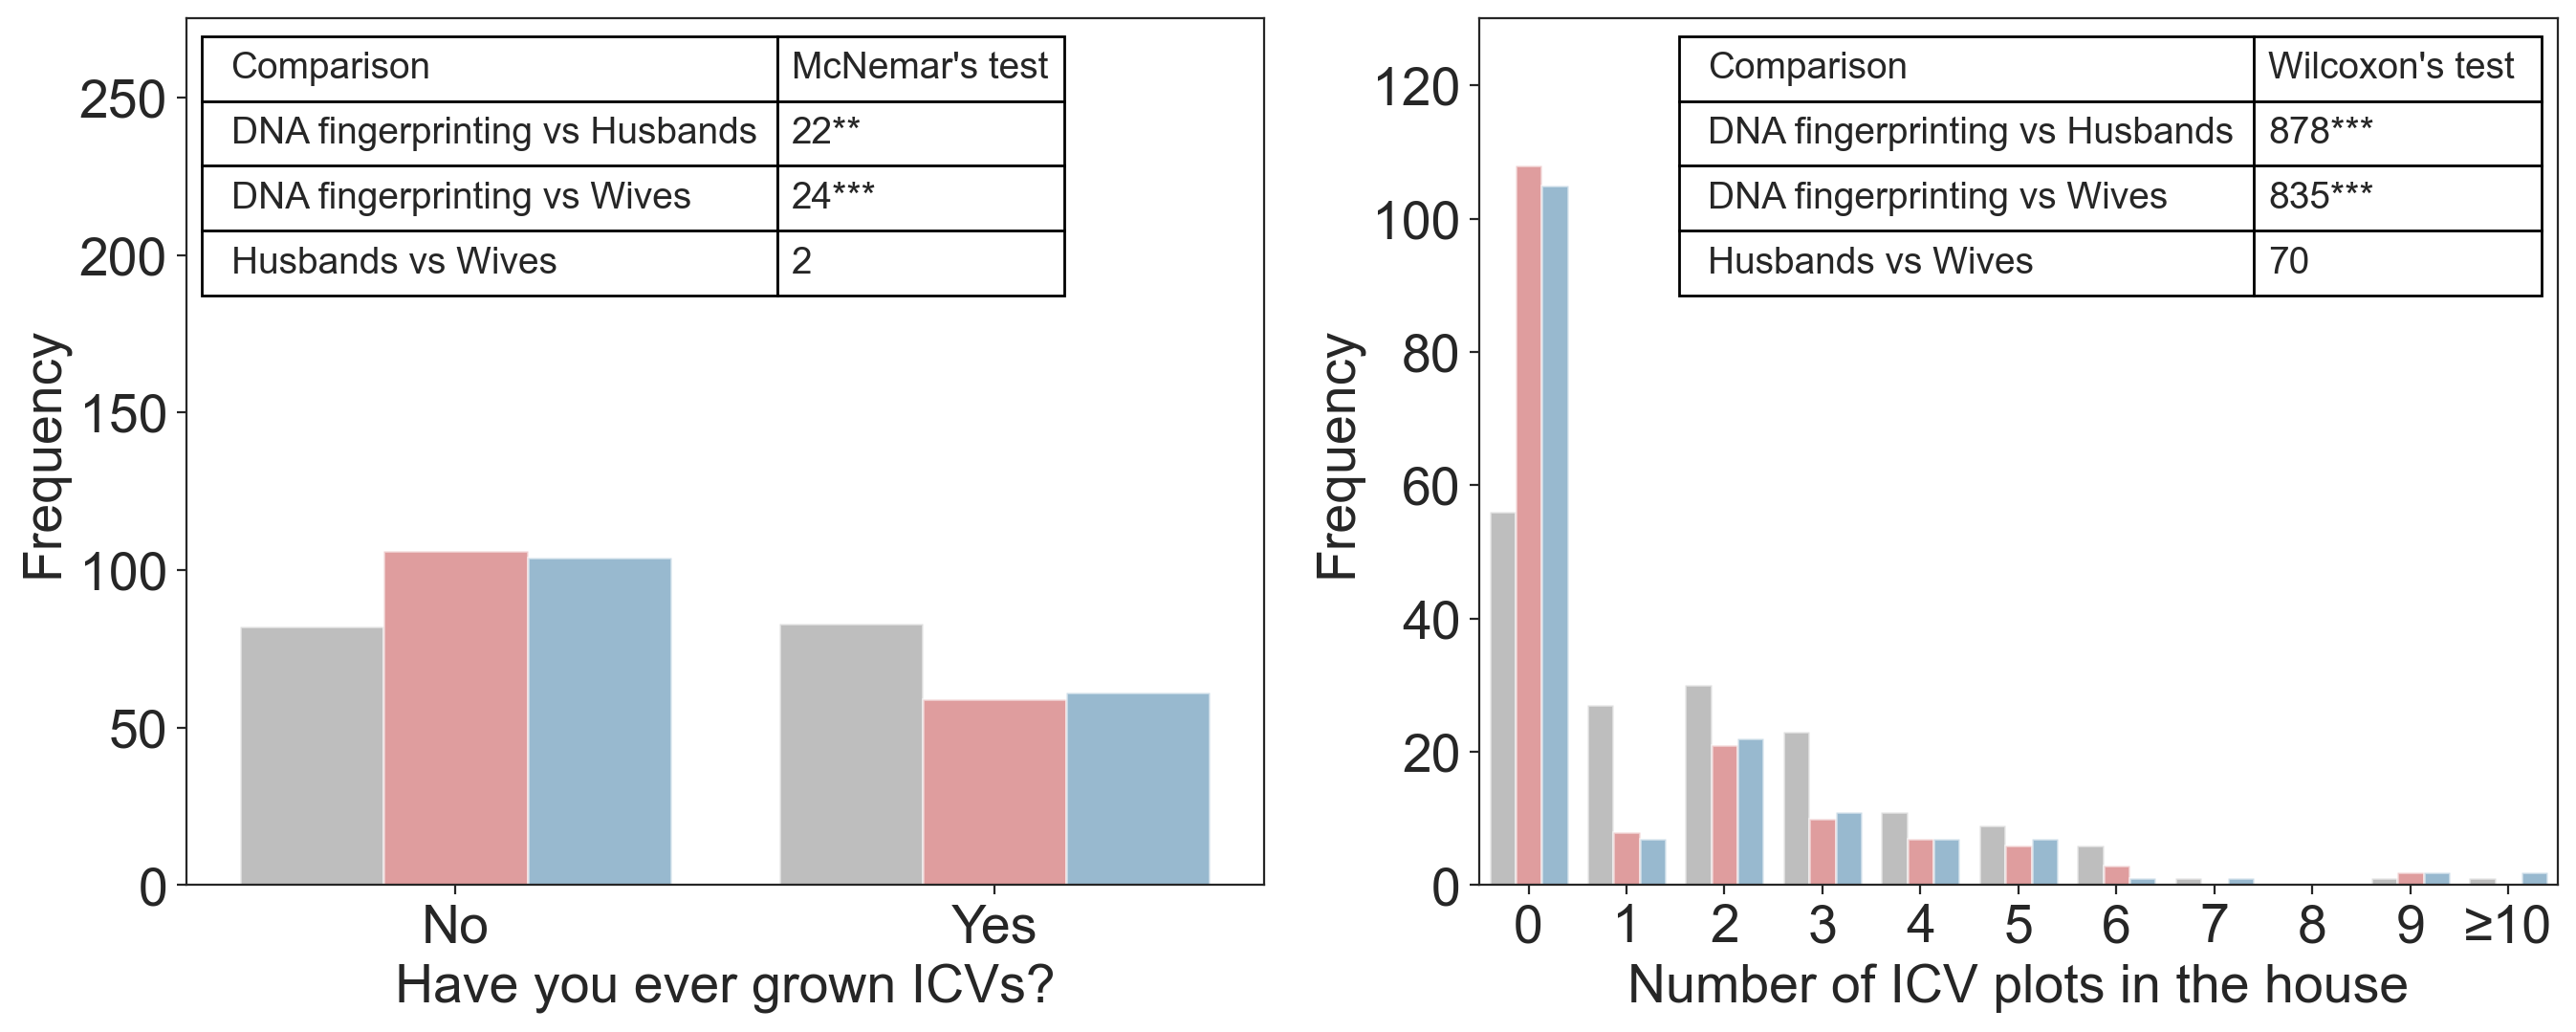

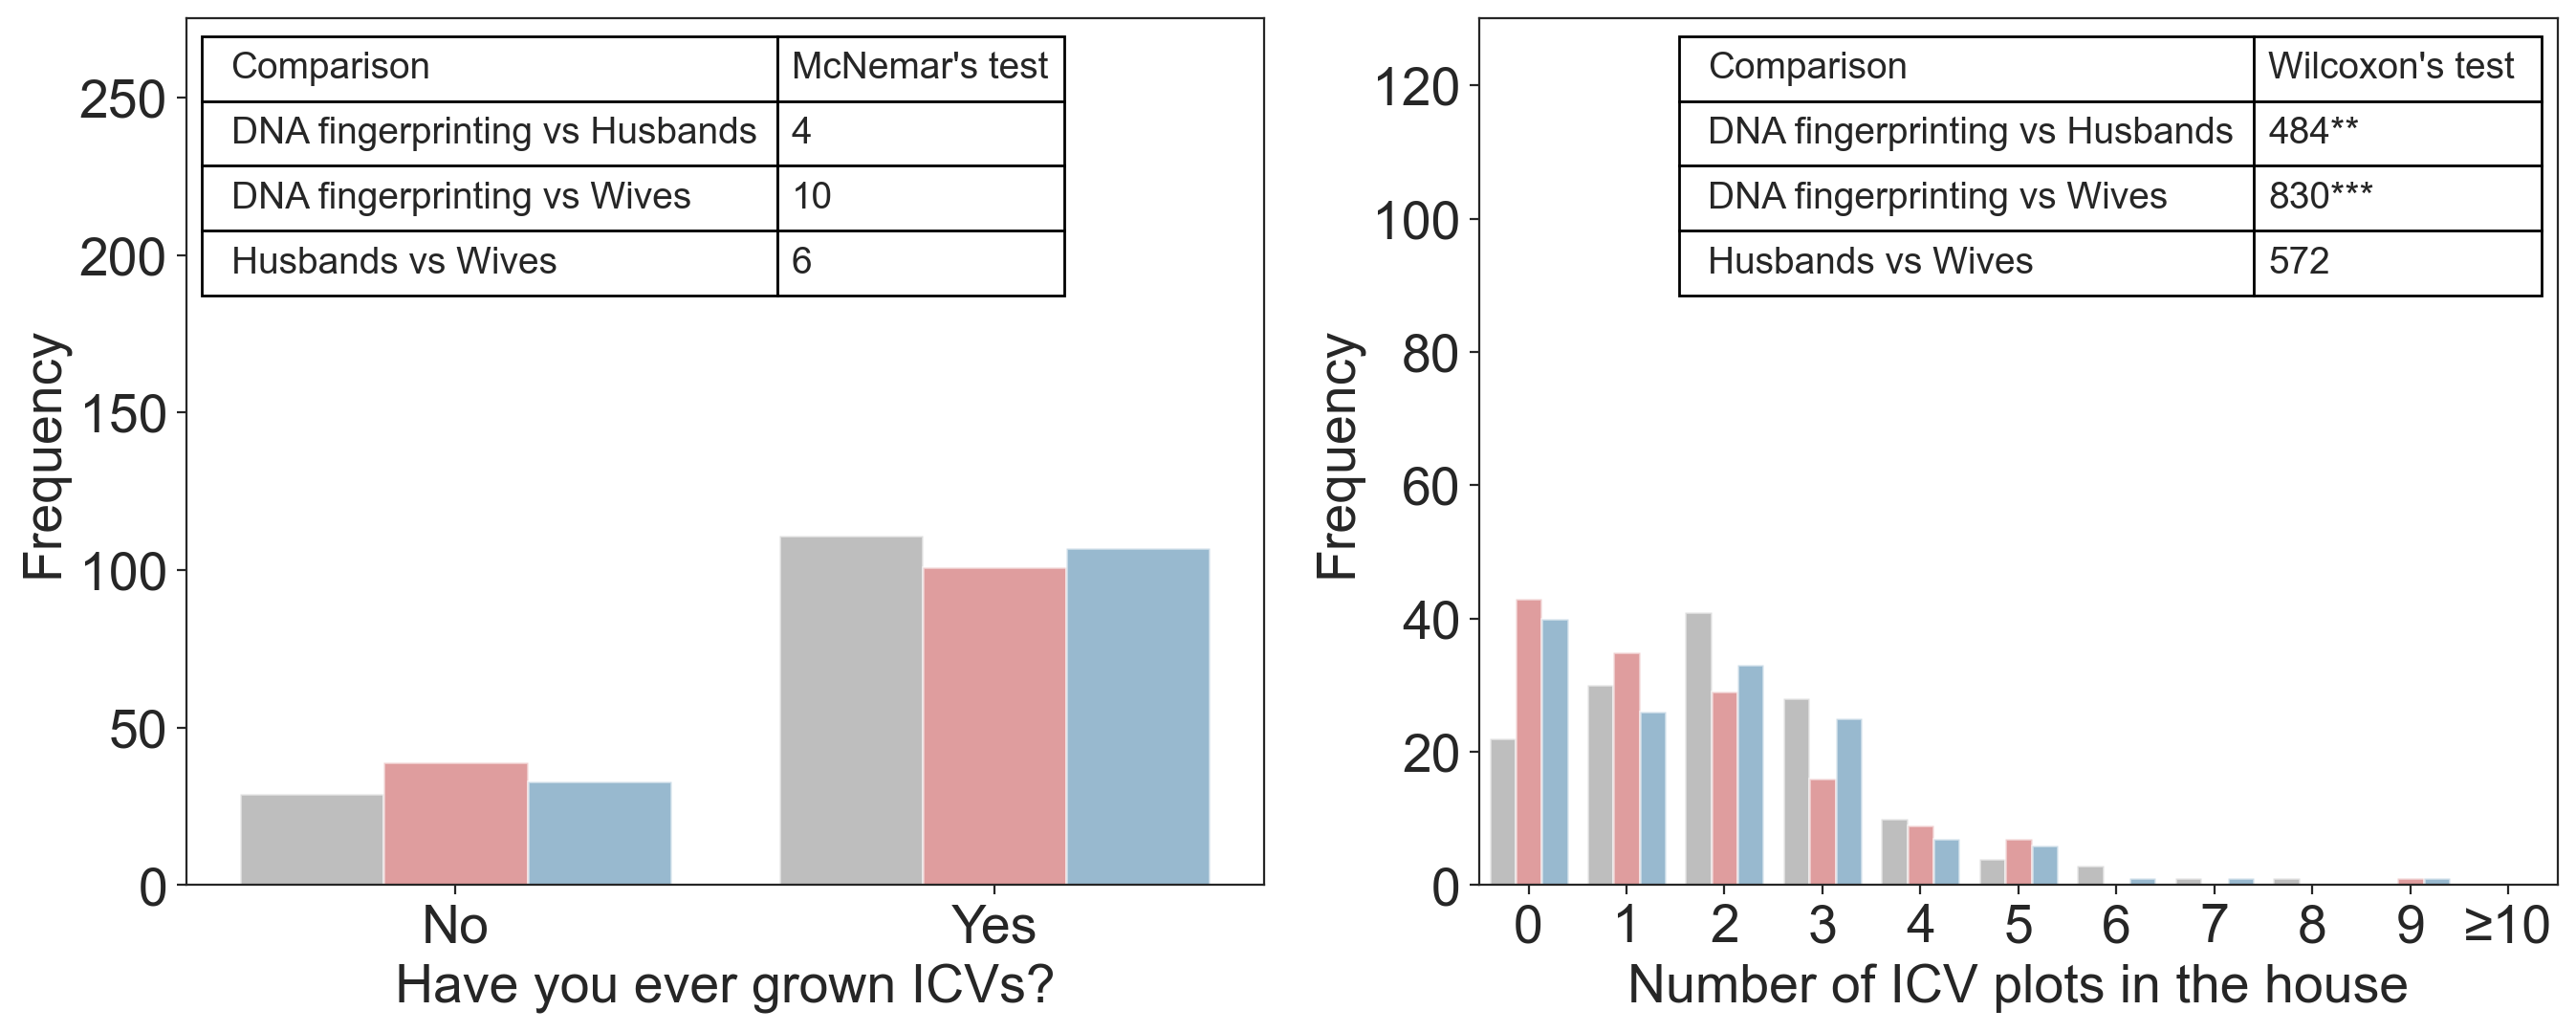

In [78]:
for zone in summary['ZoneID'].unique():        
    fig1, ax1 = plt.subplots(1, 2, figsize=(16,6), dpi=200)
    df_H_dna = df_all_plot[df_all_plot['A02_Sex'] == 'DNA fingerprinting']
    df_M = df_all_plot[df_all_plot['A02_Sex']=='Male']
    df_F = df_all_plot[df_all_plot['A02_Sex']=='Female']

    for index, var in enumerate(['planted', 'Household_ICV']):
        df_F_tmp = df_F[df_F['ZoneID'] == zone]
        df_M_tmp = df_M[df_M['ZoneID'] == zone]
        df_H_dna_tmp = df_H_dna[df_H_dna['ZoneID'] == zone]
                
        # ttest_HM = ttest_rel(df_H_dna_tmp[f'{var}'], df_M_tmp[f'{var}'], nan_policy='omit')
        # ttest_HF = ttest_rel(df_H_dna_tmp[f'{var}'], df_F_tmp[f'{var}'], nan_policy='omit')
        # ttest_MF = ttest_rel(df_M_tmp[f'{var}'], df_F_tmp[f'{var}'], nan_policy='omit')
    
        if var == "planted":
            # McNemar test (binary outcome)
            ttest_HM = mcnemar_paired(df_H_dna_tmp[var], df_M_tmp[var])
            ttest_HF = mcnemar_paired(df_H_dna_tmp[var], df_F_tmp[var])
            ttest_MF = mcnemar_paired(df_M_tmp[var], df_F_tmp[var])
            column_names = ['Comparison', 'McNemar\'s test']
        else:
            # Wilcoxon signed-rank test (count outcome)
            ttest_HM = wilcoxon(df_H_dna_tmp[var], df_M_tmp[var], nan_policy="omit")
            ttest_HF = wilcoxon(df_H_dna_tmp[var], df_F_tmp[var], nan_policy="omit")
            ttest_MF = wilcoxon(df_M_tmp[var], df_F_tmp[var], nan_policy="omit")
            column_names = ['Comparison', 'Wilcoxon\'s test']


        data = []
        data.append(['DNA fingerprinting vs Husbands', convert_pvalue(ttest_HM[0], ttest_HM[1])])
        data.append(['DNA fingerprinting vs Wives', convert_pvalue(ttest_HF[0], ttest_HF[1])])
        data.append(['Husbands vs Wives', convert_pvalue(ttest_MF[0], ttest_MF[1])])
    
        df_ttest = pd.DataFrame(data, columns = column_names)
    
        sns.barplot(summary[(summary['ZoneID'] == zone)& (summary['variable'] == var)], x='level',  y='count',
                    ax = ax1[index], 
                    hue="A02_Sex", errorbar=None, palette=["C7", "C3", "C0"], alpha=0.5)
        ax1[index].set_xlabel(var)
        
        bbox_place = (0.015, 0.68, 0.8, 0.3) if index == 0 else (0.185, 0.68, 0.8, 0.3)
        the_table = ax1[index].table(cellText=df_ttest.values, colLabels=df_ttest.columns, 
                colLoc='right', colWidths=[0.6, 0.3], bbox = bbox_place,  zorder=10)
        the_table.auto_set_font_size(False)
        the_table.set_fontsize(14)
                
        # Remove left padding from all columns
        for i in range(len(df_ttest.values)):
            set_pad_for_column(the_table, i)
        
        ax1[index].set_ylabel('Frequency')
        ax1[index].set_xlabel('Have you ever grown ICVs?' if var == 'planted' else 'Number of ICV plots in the house')

    h, l = ax1[0].get_legend_handles_labels()
    ax1[0].legend_.remove()
    ax1[1].legend_.remove()
    ax1[0].set_ylim(0, 275)
    ax1[1].set_ylim(0, 130)
    ax1[0].set_yticks([i for i in range(0, 260, 50)])
    ax1[1].set_yticks([i for i in range(0, 130, 20)])
    if zone == 1:
        fig1.legend(h, l, loc='upper center', ncols=3, bbox_to_anchor=(0.5, 1))

    fig1.savefig(f"../Manuscript/Figures/Figure_3_{update_zone(zone)}.pdf", dpi=600, bbox_inches='tight' )

# Gender and DNA fingerprinting HHhead
**Merge:** CMS Responses and  DNA fingerprinting

In [81]:
# https://data.iita.org/dataset/the-cassava-monitoring-survey-cms-in-nigeria-household-and-plot-level-data
df_DNA = pd.read_csv("../Data/CMS-raw/dna.csv")
houseIDs = df_CMS['HouseID'].value_counts().keys()
df_DNA = df_DNA[df_DNA['HouseID'].isin(houseIDs)].groupby('HouseID', as_index=False).agg(
    {'StateID': 'min', 'adoption': ['sum', 'min']})
df_DNA.columns = ['HouseID', 'ZoneID', 'Total ICV - DNA', 'Y_N ICV - DNA']
df_DNA['ZoneID'] = (df_DNA['ZoneID']/10).astype(int)#.tail()
df_DNA.shape# ()

df_CMS_HH  = df_CMS#[df_CMS['A06_Relatn_hhd'] == 'Household head']
df_CMS_HH  = df_CMS_HH.rename(columns={'Household_ICV': 'Total ICV - Survey', 'planted': 'Y_N ICV - Survey',})
df_CMS_HH_DNA = pd.merge(df_DNA, df_CMS_HH[['HouseID', 'A02_Sex', 'Total ICV - Survey', 'Y_N ICV - Survey']], on='HouseID')
print('CMS + DNA dimensions', df_CMS_HH_DNA.shape)
print('Percentaje', df_CMS_HH_DNA['A02_Sex'].value_counts(normalize=True))
df_CMS_HH_DNA.head()

CMS + DNA dimensions (2477, 7)
Percentaje A02_Sex
Male      0.779798
Female    0.220202
Name: proportion, dtype: float64


,HouseID,ZoneID,Total ICV - DNA,Y_N ICV - DNA,A02_Sex,Total ICV - Survey,Y_N ICV - Survey
0,112111,1,1,1,Male,1.0,0.0
1,112112,1,1,1,Male,0.0,0.0
2,112113,1,3,1,Male,3.0,1.0
3,112114,1,0,0,Female,0.0,0.0
4,112115,1,0,0,Male,0.0,0.0


In [82]:
df = df_CMS_HH_DNA.copy()  # your dataset


def bucket_icv(x):
    xnum = pd.to_numeric(x, errors="coerce")
    return np.where(xnum >= 10, "≥10", xnum.round().astype("Int64").astype(str))

# ---- Construct tidy long table ----
long = pd.concat([
    # DNA planted
    df.assign(source="DNA", variable="planted",
              level=df["Y_N ICV - DNA"].map({0: "No", 1: "Yes"})),

    # DNA Household_ICV
    df.assign(source="DNA", variable="Household_ICV",
              level=bucket_icv(df["Total ICV - DNA"])),

    # Survey planted
    df.assign(source="Survey", variable="planted",
              level=df["Y_N ICV - Survey"].map({0: "No", 1: "Yes"})),

    # Survey Household_ICV
    df.assign(source="Survey", variable="Household_ICV",
              level=bucket_icv(df["Total ICV - Survey"]))
], ignore_index=True)[["ZoneID", "A02_Sex", "source", "variable", "level"]]

# ---- Define orderings ----
planted_order = ["No", "Yes"]
icv_order = [str(i) for i in range(10)] + ["≥10"]
var_order = ["planted", "Household_ICV"]

# ---- Count and zero-fill missing combinations ----
counts = (long.groupby(["ZoneID", "A02_Sex", "source", "variable", "level"])
               .size()
               .rename("count")
               .reset_index())

zone_vals = df["ZoneID"].unique()
sex_vals = df["A02_Sex"].unique()
sources = ["DNA", "Survey"]

# Generate full index for zero fill
parts = []
for var, lvls in {"planted": planted_order, "Household_ICV": icv_order}.items():
    part = pd.MultiIndex.from_product(
        [zone_vals, sex_vals, sources, [var], lvls],
        names=["ZoneID", "A02_Sex", "source", "variable", "level"]
    )
    parts.append(part)
full_index = parts[0].append(parts[1])

summary_cms = (counts.set_index(["ZoneID","A02_Sex","source","variable","level"])
                 .reindex(full_index, fill_value=0)
                 .reset_index())

# ---- Order properly for plotting ----
summary_cms["variable"] = pd.Categorical(summary_cms["variable"], categories=var_order, ordered=True)
summary_cms["level"] = summary_cms.apply(
    lambda r: pd.Categorical(
        [r["level"]],
        categories=planted_order if r["variable"] == "planted" else icv_order,
        ordered=True
    )[0],
    axis=1
)

summary_cms = summary_cms.sort_values(["ZoneID", "A02_Sex", "source", "variable", "level"]).reset_index(drop=True)
print(summary_cms.head(20))

    ZoneID A02_Sex  source       variable level  count
0        1  Female     DNA        planted    No     35
1        1  Female     DNA        planted   Yes     32
2        1  Female     DNA  Household_ICV     0     19
3        1  Female     DNA  Household_ICV     1     18
4        1  Female     DNA  Household_ICV     2     20
5        1  Female     DNA  Household_ICV     3      7
6        1  Female     DNA  Household_ICV     4      1
7        1  Female     DNA  Household_ICV     5      1
8        1  Female     DNA  Household_ICV     6      0
9        1  Female     DNA  Household_ICV     7      1
10       1  Female     DNA  Household_ICV     8      0
11       1  Female     DNA  Household_ICV     9      0
12       1  Female     DNA  Household_ICV   ≥10      0
13       1  Female  Survey        planted    No     28
14       1  Female  Survey        planted   Yes     39
15       1  Female  Survey  Household_ICV     0     30
16       1  Female  Survey  Household_ICV     1     15
17       1

/var/folders/y5/00tzypd935b1wg86qc9l9jcw0000gn/T/ipykernel_27117/4101003553.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = (long.groupby(["ZoneID", "A02_Sex", "source", "variable", "level"])


['planted', 'Household_ICV']
Categories (2, object): ['planted' < 'Household_ICV']


/var/folders/y5/00tzypd935b1wg86qc9l9jcw0000gn/T/ipykernel_27117/3925460224.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_all_plot_summary_cms = summary_cms[summary_cms['variable'] == var].groupby(['A02_Sex', 'source', 'variable', 'level']).sum().reset_index()
/var/folders/y5/00tzypd935b1wg86qc9l9jcw0000gn/T/ipykernel_27117/3925460224.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_all_plot_summary_cms = summary_cms[summary_cms['variable'] == var].groupby(['A02_Sex', 'source', 'variable', 'level']).sum().reset_index()


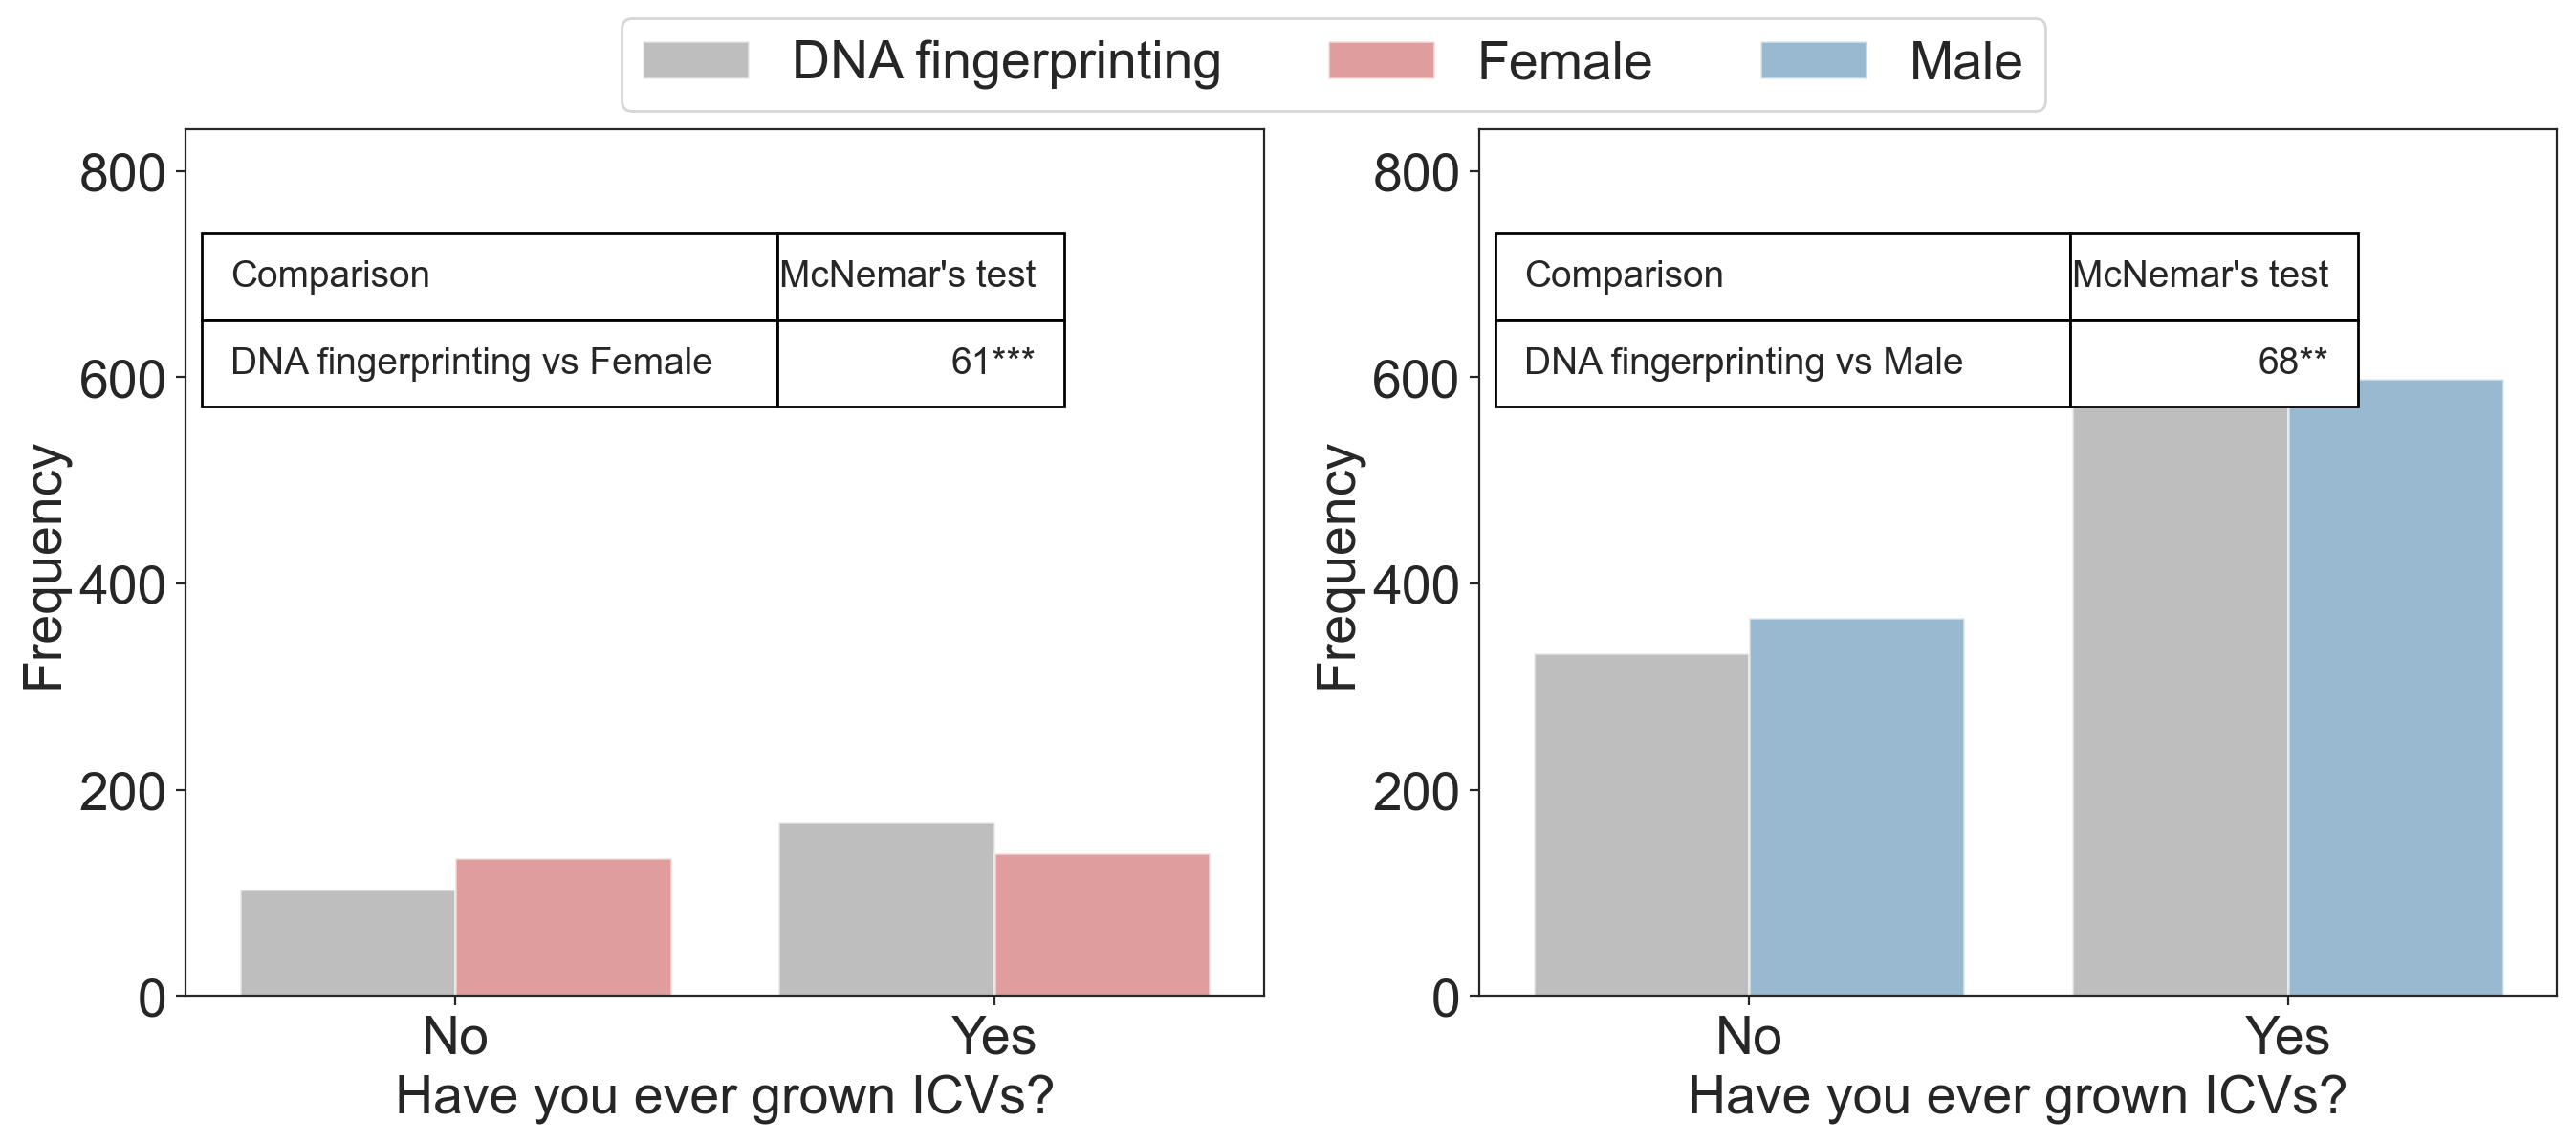

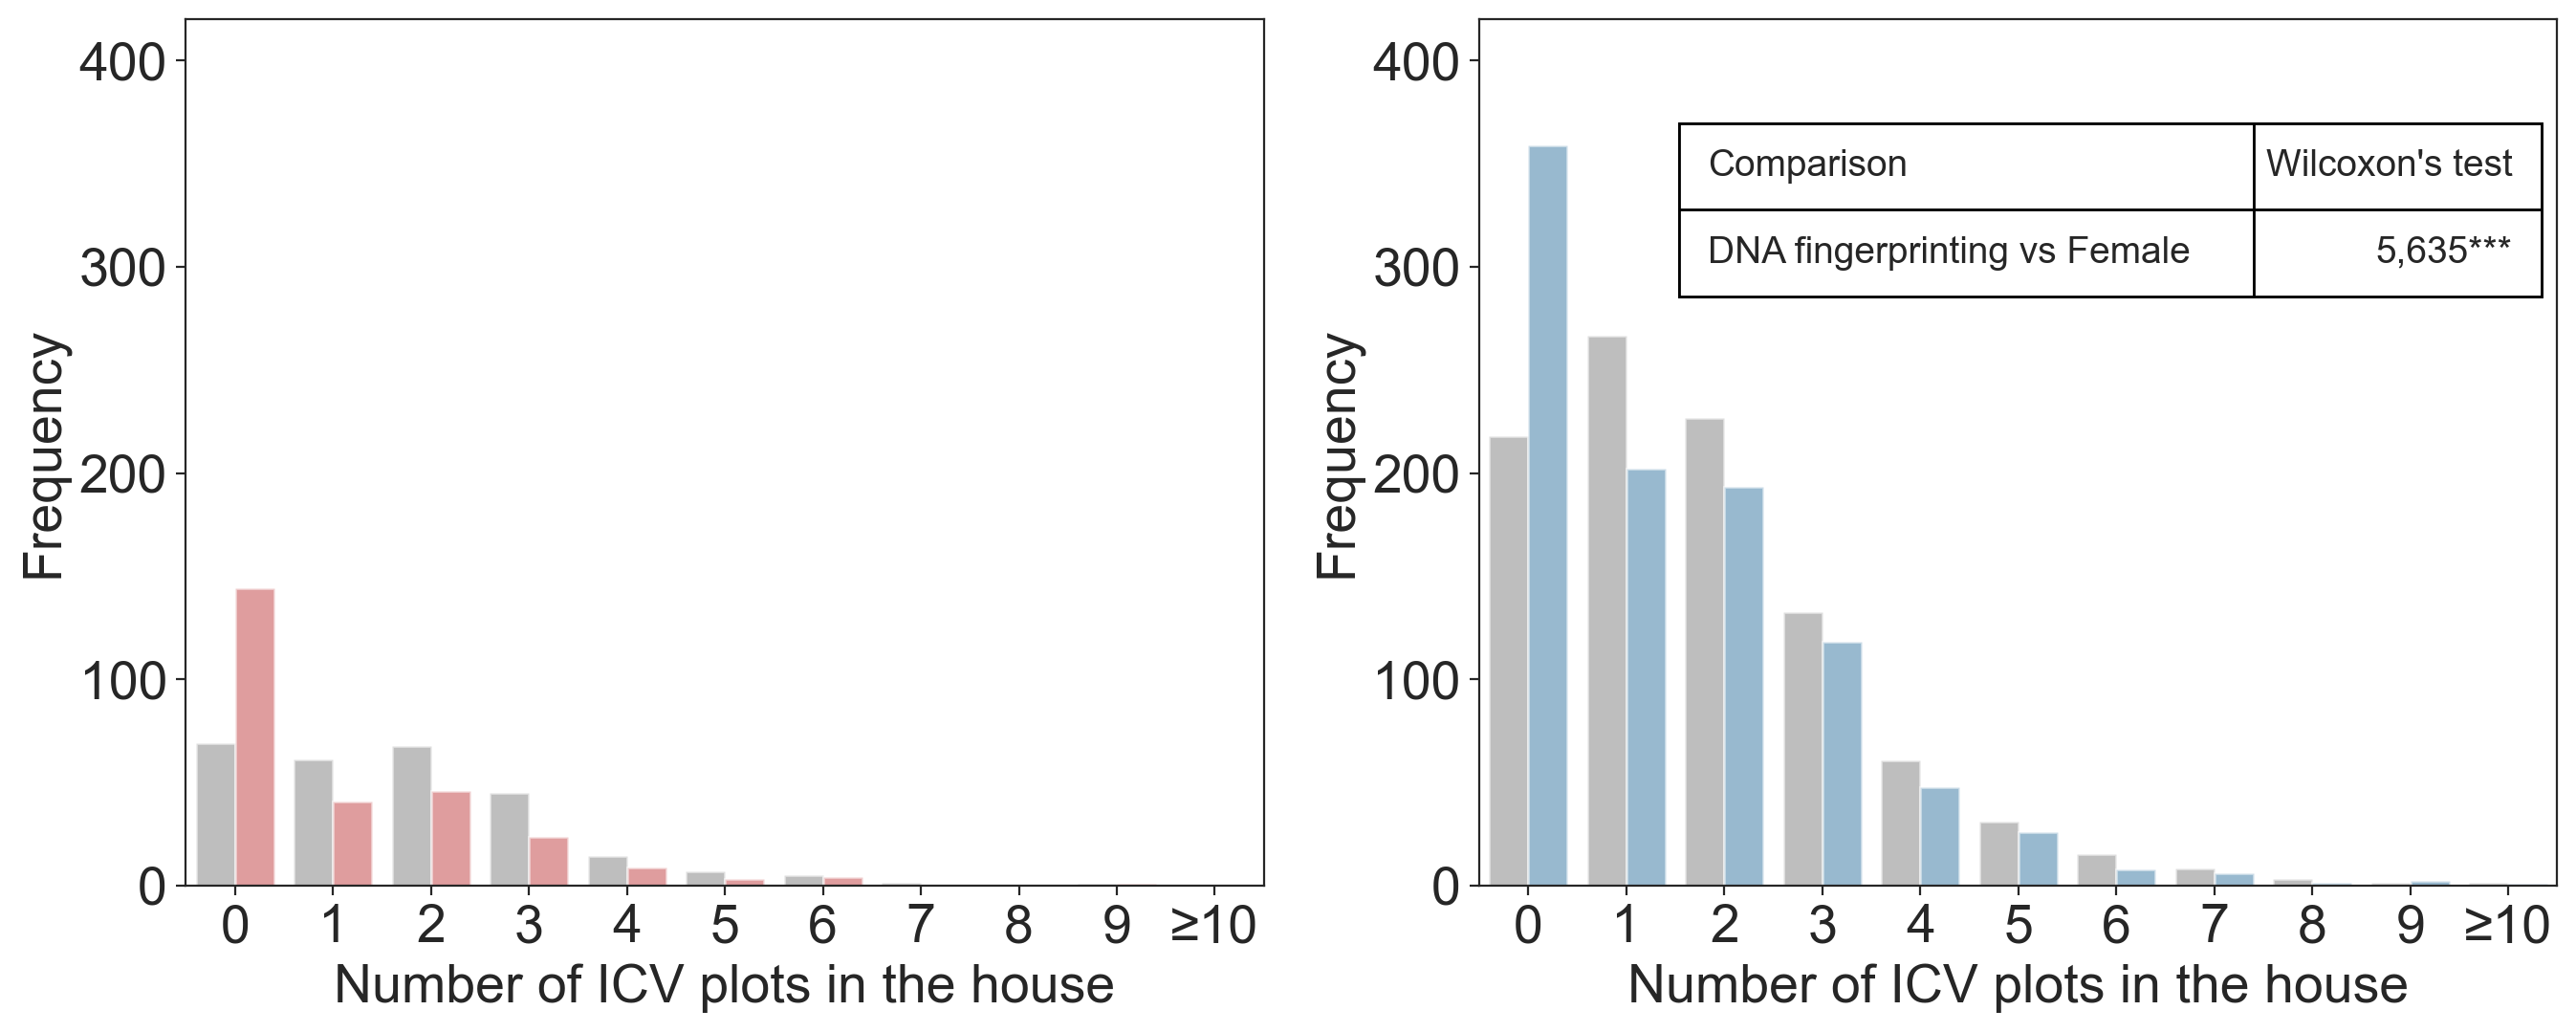

In [ ]:
# plt.rcParams.update({'font.size': 18})

df_M = df_CMS_HH_DNA[df_CMS_HH_DNA['A02_Sex'] == 'Male']#[['Total ICV - Survey', 'Total ICV - DNA', 'Y/N ICV - DNA']]
df_F = df_CMS_HH_DNA[df_CMS_HH_DNA['A02_Sex'] == 'Female']#[['Total ICV - Survey', 'Total ICV - DNA', ]]
df_DNA.keys()


df_M = df_CMS_HH_DNA[df_CMS_HH_DNA['A02_Sex'] == 'Male']#[['Total ICV - Survey', 'Total ICV - DNA', 'Y/N ICV - DNA']]
df_F = df_CMS_HH_DNA[df_CMS_HH_DNA['A02_Sex'] == 'Female']#[['Total ICV - Survey', 'Total ICV - DNA', ]]
print(summary_cms['variable'].unique())
for index, var in enumerate(summary_cms['variable'].unique()):

    fig1, ax1 = plt.subplots(1, 2, figsize=(16,6), dpi=200)
    var_tmp = 'Y_N ICV' if var == 'planted' else 'Total ICV'
    
    if var == 'planted':
        # McNemar test (binary outcome)
        ttest_HM = mcnemar_paired(df_M[f'{var_tmp} - DNA'], df_M[f'{var_tmp} - Survey'])
        ttest_HF = mcnemar_paired(df_F[f'{var_tmp} - DNA'], df_F[f'{var_tmp} - Survey'])
        column_names = ['Comparison', 'McNemar\'s test']
    else:
        # Paired t-test (count outcome)  
        ttest_HM = wilcoxon(df_M[f'{var_tmp} - DNA'], df_M[f'{var_tmp} - Survey'], nan_policy='omit')
        ttest_HF = wilcoxon(df_F[f'{var_tmp} - DNA'], df_F[f'{var_tmp} - Survey'], nan_policy='omit')
        column_names = ['Comparison', 'Wilcoxon\'s test']
    
    df_all_plot_summary_cms = summary_cms[summary_cms['variable'] == var].groupby(['A02_Sex', 'source', 'variable', 'level']).sum().reset_index() 

    sns.barplot(df_all_plot_summary_cms[(df_all_plot_summary_cms['A02_Sex'] == 'Male')], x='level',  y='count',
                    ax = ax1[1], 
                    hue="source", errorbar=None, palette=["C7", "C0"], alpha=0.5)
    
    sns.barplot(df_all_plot_summary_cms[(df_all_plot_summary_cms['A02_Sex'] == 'Female')], x='level',  y='count',
                    ax = ax1[0], 
                    hue="source", errorbar=None, palette=["C7", "C3"], alpha=0.5)

    # bbox_place = (0.015, 0.68, 0.8, 0.2) if index == 0 else (0.185, 0.68, 0.8, 0.2)
    bbox_place = (0.015, 0.78, 0.7, 0.2) if index == 0 else (0.285, 0.78, 0.7, 0.2)

    data = []
    data.append(['DNA fingerprinting vs Male', convert_pvalue(ttest_HM[0], ttest_HM[1])])
    df_ttest = pd.DataFrame(data, columns = column_names)
    the_table = ax1[1].table(cellText=df_ttest.values, colLabels=df_ttest.columns, 
              colLoc='right', colWidths=[0.6, 0.3], bbox = bbox_place,  zorder=10)
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(14)
            
    # Remove left padding from all columns
    for i in range(len(df_ttest.values)):
        set_pad_for_column(the_table, i)
    
    
    # ax1[1].set_title('Female')
    data = []
    data.append(['DNA fingerprinting vs Female', convert_pvalue(ttest_HF[0], ttest_HF[1])])
    df_ttest = pd.DataFrame(data, columns = column_names)

    the_table = ax1[index].table(cellText=df_ttest.values, colLabels=df_ttest.columns, 
            colLoc='right', colWidths=[0.6, 0.3], bbox = bbox_place,  zorder=10)
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(14)


            
    # Remove left padding from all columns
    for i in range(len(df_ttest.values)):
        set_pad_for_column(the_table, i)

        
    ax1[0].set_ylabel('Frequency')
    ax1[1].set_ylabel('Frequency')

    # h, l = ax1[0].get_legend_handles_labels()
    ax1[0].legend_.remove()
    ax1[1].legend_.remove()


    if index == 0:
        fig1.legend(h, l, loc='upper center', ncols=3, bbox_to_anchor=(0.5, 1))
        ax1[0].set_ylim(0, 840)
        ax1[1].set_ylim(0, 840)
        ax1[0].set_yticks([i for i in range(0, 810, 200)])
        ax1[1].set_yticks([i for i in range(0, 810, 200)])
        ax1[0].set_xlabel('Have you ever grown ICVs?' )
        ax1[1].set_xlabel('Have you ever grown ICVs?' )

    else:
        ax1[0].set_ylim(0, 420)
        ax1[1].set_ylim(0, 420)
        ax1[0].set_yticks([i for i in range(0, 410, 100)])
        ax1[1].set_yticks([i for i in range(0, 410, 100)])
        ax1[0].set_xlabel('Number of ICV plots in the house' )
        ax1[1].set_xlabel('Number of ICV plots in the house')

    fig1.savefig(f"../Manuscript/Figures/Figure_4_{var}.pdf", dpi=600, bbox_inches='tight' )

# Household composition by Plot

In [11]:
path_raw =  '../Data/drive-download-20231006T131216Z-001/Files/Data Cleaning - Individual Files/Original Files - Not Cleaned/CMS (entire database)/Files/'
df_HHcomposition = pd.read_stata(path_raw + 'Cassava_Plot_All regions _dr tunji_Nike_var_coded.dta')  
df_HHcomposition# ['D08_Plot_manager'].value_counts()

,ZoneID,StateID,LgaID,LocalityID,EnumerationID,HouseID,CassavaPlotInformationID,D01_Fieldcode,D02_Field_locname,D03_Plotcode,...,D06_1_D_Prop_var4,D06_1_E_cassav_var,Var5_recoded,D06_1_E_loc_imp,D06_1_E_Prop_var5,D06_1_F_Hundred_PercentCheck,D07_dist_km,D08_Plot_manager,D09_Soil_fertility_status,percentimproved
0,1.0,11.0,112.0,1121.0,11211.0,112111.0,1.0,F1,,1.0,...,0.0,,NaN,Local,0.0,Yes,3.0,Men,Good,60.0
1,1.0,11.0,112.0,1121.0,11211.0,112112.0,1.0,F1,Cassava Farm,1.0,...,0.0,,NaN,Local,0.0,Yes,2.0,Men,Good,0.0
2,1.0,11.0,112.0,1121.0,11211.0,112113.0,1.0,F1,Aluju Farm,1.0,...,20.0,,NaN,Local,0.0,Yes,5.0,Both equally,Medium,20.0
3,1.0,11.0,112.0,1121.0,11211.0,112113.0,2.0,F1,Aluju Farm,2.0,...,30.0,,NaN,Local,0.0,Yes,5.0,Both equally,Medium,30.0
4,1.0,11.0,112.0,1121.0,11211.0,112113.0,3.0,F2,Anyaro Farm,1.0,...,30.0,,NaN,Local,0.0,Yes,5.3,Both equally,Good,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6252,4.0,43.0,4320.0,43201.0,432011.0,4320114.0,1.0,F1,Adayon quaters,1.0,...,0.0,,NaN,Local,0.0,Yes,0.5,Both equally,Good,0.0
6253,4.0,43.0,4320.0,43201.0,432011.0,4320115.0,1.0,F1,Baptist Church Road,1.0,...,0.0,,NaN,Local,0.0,Yes,1.0,Both equally,Medium,0.0
6254,4.0,43.0,4320.0,43201.0,432011.0,4320115.0,2.0,F1,Baptist Church Road,2.0,...,0.0,,NaN,Local,0.0,Yes,1.0,Both equally,Medium,0.0
6255,4.0,43.0,4320.0,43201.0,432011.0,4320115.0,3.0,F2,Baptist Church Road,1.0,...,0.0,,NaN,Local,0.0,Yes,1.3,Both equally,Medium,0.0


In [12]:
df_DNA = pd.read_csv("../Data/CMS-raw/dna.csv")
houseIDs = df_CMS['HouseID'].value_counts().keys()
df_DNA = df_DNA[df_DNA['HouseID'].isin(houseIDs)]
df_merge = df_DNA.merge(df_HHcomposition[['HouseID', 'CassavaPlotInformationID', 'D08_Plot_manager', 'percentimproved']], 
                        on=['HouseID', 'CassavaPlotInformationID'])

df_merge = pd.get_dummies(df_merge, dtype=int)
df_merge = df_merge[df_merge.columns[1:5].tolist() + ['adoption'] + df_merge.columns[-4:].tolist()]

def cleanManagedICV(x):
    return x[x.keys()[0]] if int(x[x.keys()[1]]) > 0 else 0
        
df_merge['D08_Plot_manager_Women'] = df_merge[['D08_Plot_manager_Women','adoption']].apply(cleanManagedICV, axis = 1)
df_merge['D08_Plot_manager_Men'] = df_merge[['D08_Plot_manager_Men','adoption']].apply(cleanManagedICV, axis = 1)
df_merge['D08_Plot_manager_Both equally'] = df_merge[['D08_Plot_manager_Both equally','adoption']].apply(cleanManagedICV, axis = 1)

df_merge[df_merge.columns[2: ]]

,HouseID,CassavaPlotInformationID,adoption,percentimproved,D08_Plot_manager_Women,D08_Plot_manager_Men,D08_Plot_manager_Both equally
0,112111,1,1,60.0,0,1,0
1,112112,1,1,0.0,0,1,0
2,112113,1,1,20.0,0,0,1
3,112113,2,1,30.0,0,0,1
4,112113,3,1,30.0,0,0,1
...,...,...,...,...,...,...,...
6370,4320114,1,1,0.0,0,0,1
6371,4320115,1,0,0.0,0,0,0
6372,4320115,2,0,0.0,0,0,0
6373,4320115,3,0,0.0,0,0,0


## Merge by Household

In [13]:
df_merge = df_merge.groupby('HouseID', as_index=False).agg(
            {'StateID': 'min', 'adoption': ['sum', 'min'], 
             'D08_Plot_manager_Women' : ['sum'],
             'D08_Plot_manager_Men' : ['sum'], 
             'D08_Plot_manager_Both equally': ['sum']})

df_merge.columns = ['HouseID', 'ZoneID', 'Total ICV - DNA', 'Y_N ICV - DNA', 
                   'Total ICV Female - DNA', 'Total ICV Male - DNA', 'Total ICV Joint - DNA']
df_merge['ZoneID'] = (df_merge['ZoneID']/10).astype(int)#.tail()

df_merge

,HouseID,ZoneID,Total ICV - DNA,Y_N ICV - DNA,Total ICV Female - DNA,Total ICV Male - DNA,Total ICV Joint - DNA
0,112111,1,1,1,0,1,0
1,112112,1,1,1,0,1,0
2,112113,1,3,1,0,0,3
3,112114,1,0,0,0,0,0
4,112115,1,0,0,0,0,0
...,...,...,...,...,...,...,...
2472,4320111,4,2,1,2,0,0
2473,4320112,4,2,1,0,0,2
2474,4320113,4,1,1,0,1,0
2475,4320114,4,1,1,0,0,1


## Merge with CMS data

In [14]:
df_CMS_HH  = df_CMS#[df_CMS['A06_Relatn_hhd'] == 'Household head']
df_CMS_HH  = df_CMS_HH.rename(columns={'Household_ICV': 'Total ICV - Survey', 'planted': 'Y_N ICV - Survey', 
                                       'Male_ICV_Managed': 'Total ICV Male - Survey', 'Female_ICV_Managed': 'Total ICV Female - Survey', 
                                       'Joint_ICV_Managed': 'Total ICV Joint - Survey'})

df_CMS_HH_DNA_byplot = pd.merge(df_merge, df_CMS_HH[['HouseID', 'A02_Sex', 'Total ICV - Survey', 'Y_N ICV - Survey', 
                                            'Total ICV Male - Survey', 'Total ICV Female - Survey', 'Total ICV Joint - Survey']], 
                         on='HouseID')
df_CMS_HH_DNA_byplot

,HouseID,ZoneID,Total ICV - DNA,Y_N ICV - DNA,Total ICV Female - DNA,Total ICV Male - DNA,Total ICV Joint - DNA,A02_Sex,Total ICV - Survey,Y_N ICV - Survey,Total ICV Male - Survey,Total ICV Female - Survey,Total ICV Joint - Survey
0,112111,1,1,1,0,1,0,Male,1.0,0.0,1.0,0.0,0.0
1,112112,1,1,1,0,1,0,Male,0.0,0.0,0.0,0.0,0.0
2,112113,1,3,1,0,0,3,Male,3.0,1.0,0.0,0.0,3.0
3,112114,1,0,0,0,0,0,Female,0.0,0.0,0.0,0.0,0.0
4,112115,1,0,0,0,0,0,Male,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2472,4320111,4,2,1,2,0,0,Female,0.0,0.0,0.0,0.0,0.0
2473,4320112,4,2,1,0,0,2,Male,1.0,1.0,0.0,0.0,1.0
2474,4320113,4,1,1,0,1,0,Male,1.0,1.0,1.0,0.0,0.0
2475,4320114,4,1,1,0,0,1,Male,0.0,0.0,0.0,0.0,0.0


In [33]:
# --- Load your dataset ---
df = df_CMS_HH_DNA_byplot.copy()

# --- Helper function to bucket totals ---
def bucket_icv(x):
    xnum = pd.to_numeric(x, errors="coerce")
    return np.where(xnum >= 10, "≥10", xnum.round().astype("Int64").astype(str))

# --- 1) Build long format only for disaggregated totals ---
long_frames = []
for src in ["DNA", "Survey"]:
    for grp in ["Female", "Male", "Joint"]:
        long_frames.append(
            df.assign(
                source=src,
                variable=f"Household_ICV_{grp}",
                level=bucket_icv(df[f"Total ICV {grp} - {src}"])
            )
        )

# Combine
long = pd.concat(long_frames, ignore_index=True)[["A02_Sex", "source", "variable", "level"]]

# --- 2) Define the order for levels ---
icv_order = [str(i) for i in range(10)] + ["≥10"]

# --- 3) Count combinations ---
counts = (
    long.groupby(["A02_Sex", "source", "variable", "level"])
    .size()
    .rename("count")
    .reset_index()
)

# --- 4) Zero-fill all missing combinations ---
sex_vals = df["A02_Sex"].dropna().unique()
sources = ["DNA", "Survey"]
variables = [f"Household_ICV_{g}" for g in ["Female", "Male", "Joint"]]

full_index_parts = [
    pd.MultiIndex.from_product(
        [sex_vals, sources, [var], icv_order],
        names=["A02_Sex", "source", "variable", "level"]
    )
    for var in variables
]
full_index = full_index_parts[0].append(full_index_parts[1:])

summary_cms_byplot = (
    counts.set_index(["A02_Sex", "source", "variable", "level"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

# --- 5) Clean sorting ---
summary_cms_byplot["variable"] = pd.Categorical(
    summary_cms_byplot["variable"],
    categories=variables,
    ordered=True
)
summary_cms_byplot["level"] = pd.Categorical(
    summary_cms_byplot["level"],
    categories=icv_order,
    ordered=True
)

summary_cms_byplot = summary_cms_byplot.sort_values(
    ["A02_Sex", "source", "variable", "level"]
).reset_index(drop=True)

print(summary_cms_byplot.tail(25))

    A02_Sex  source              variable level  count
107    Male  Survey  Household_ICV_Female     8      0
108    Male  Survey  Household_ICV_Female     9      1
109    Male  Survey  Household_ICV_Female   ≥10      0
110    Male  Survey    Household_ICV_Male     0   1272
111    Male  Survey    Household_ICV_Male     1    266
112    Male  Survey    Household_ICV_Male     2    212
113    Male  Survey    Household_ICV_Male     3    114
114    Male  Survey    Household_ICV_Male     4     35
115    Male  Survey    Household_ICV_Male     5     17
116    Male  Survey    Household_ICV_Male     6      7
117    Male  Survey    Household_ICV_Male     7      5
118    Male  Survey    Household_ICV_Male     8      0
119    Male  Survey    Household_ICV_Male     9      1
120    Male  Survey    Household_ICV_Male   ≥10      1
121    Male  Survey   Household_ICV_Joint     0   1330
122    Male  Survey   Household_ICV_Joint     1    205
123    Male  Survey   Household_ICV_Joint     2    187
124    Mal

/var/folders/y5/00tzypd935b1wg86qc9l9jcw0000gn/T/ipykernel_27117/1187341847.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  long.groupby(["A02_Sex", "source", "variable", "level"])


In [38]:
summary_cms_byplot[(summary_cms_byplot['A02_Sex'] == 'Female') & (summary_cms_byplot['variable'] == 'Household_ICV_Male')]


,A02_Sex,source,variable,level,count
11,Female,DNA,Household_ICV_Male,0,535
12,Female,DNA,Household_ICV_Male,1,4
13,Female,DNA,Household_ICV_Male,2,2
14,Female,DNA,Household_ICV_Male,3,4
15,Female,DNA,Household_ICV_Male,4,0
16,Female,DNA,Household_ICV_Male,5,0
17,Female,DNA,Household_ICV_Male,6,0
18,Female,DNA,Household_ICV_Male,7,0
19,Female,DNA,Household_ICV_Male,8,0
20,Female,DNA,Household_ICV_Male,9,0


TtestResult(statistic=4.933208974390281, pvalue=8.78275046105648e-07, df=1929)
['DNA fingerprinting vs Self-reported', '4.933***']
['DNA fingerprinting vs Self-reported', '-0.258']
TtestResult(statistic=2.4665654658216885, pvalue=0.013727938458637502, df=1929)
['DNA fingerprinting vs Self-reported', '2.467**']
['DNA fingerprinting vs Self-reported', '8.105***']
TtestResult(statistic=7.139471087188831, pvalue=1.3213623236088887e-12, df=1929)
['DNA fingerprinting vs Self-reported', '7.139***']
['DNA fingerprinting vs Self-reported', '4.706***']


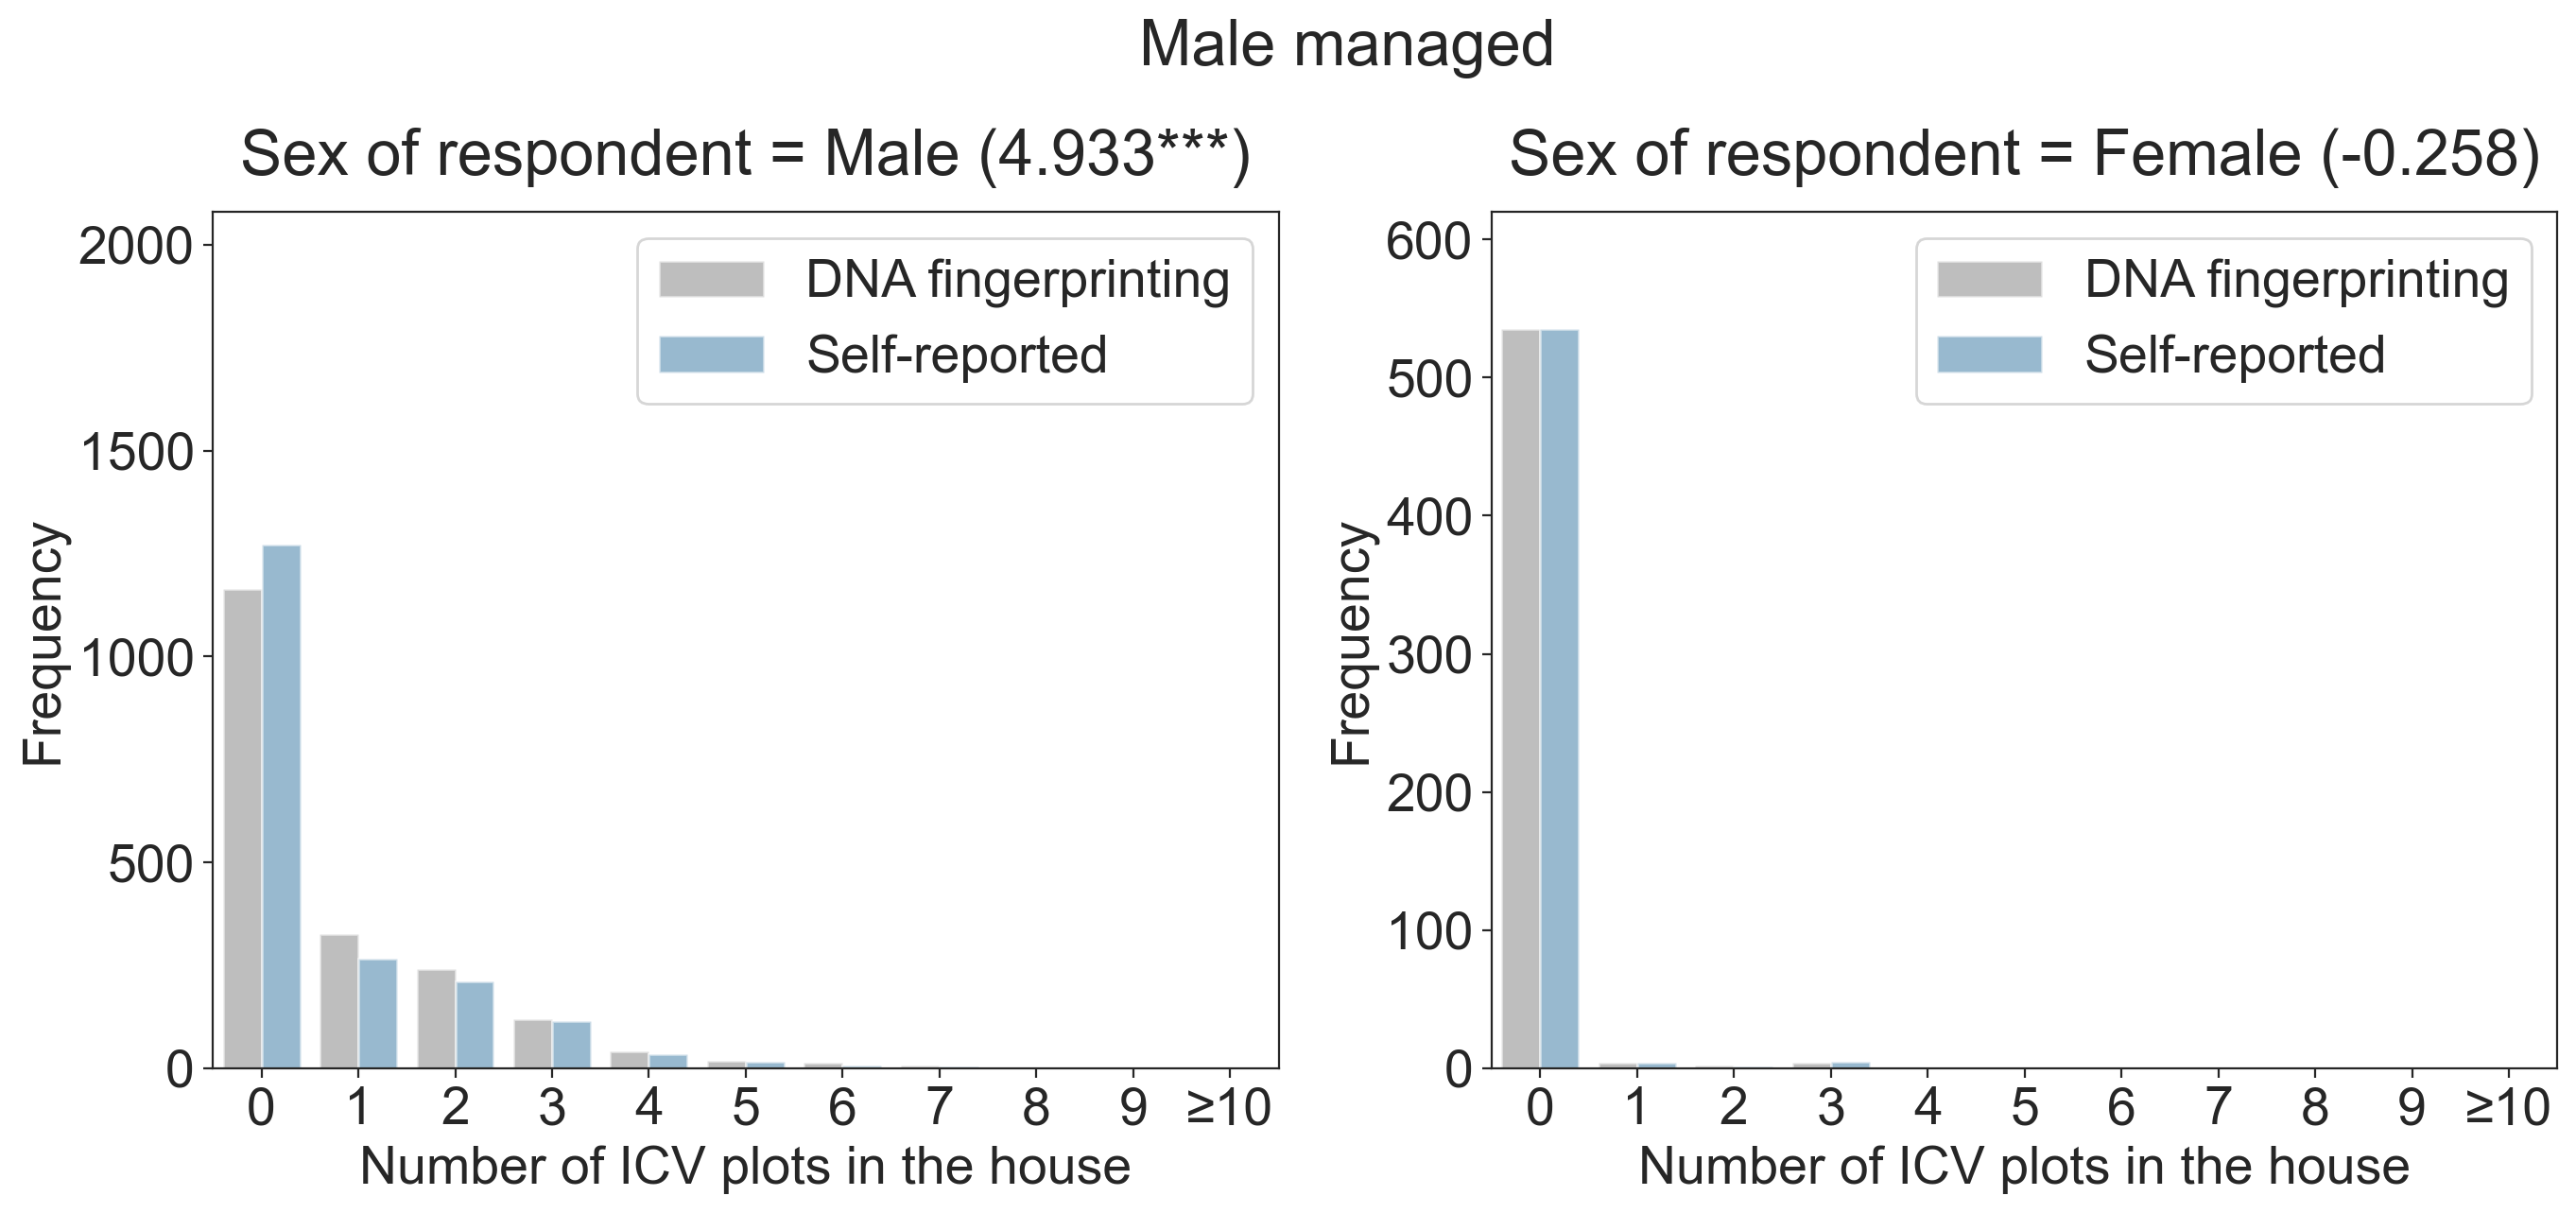

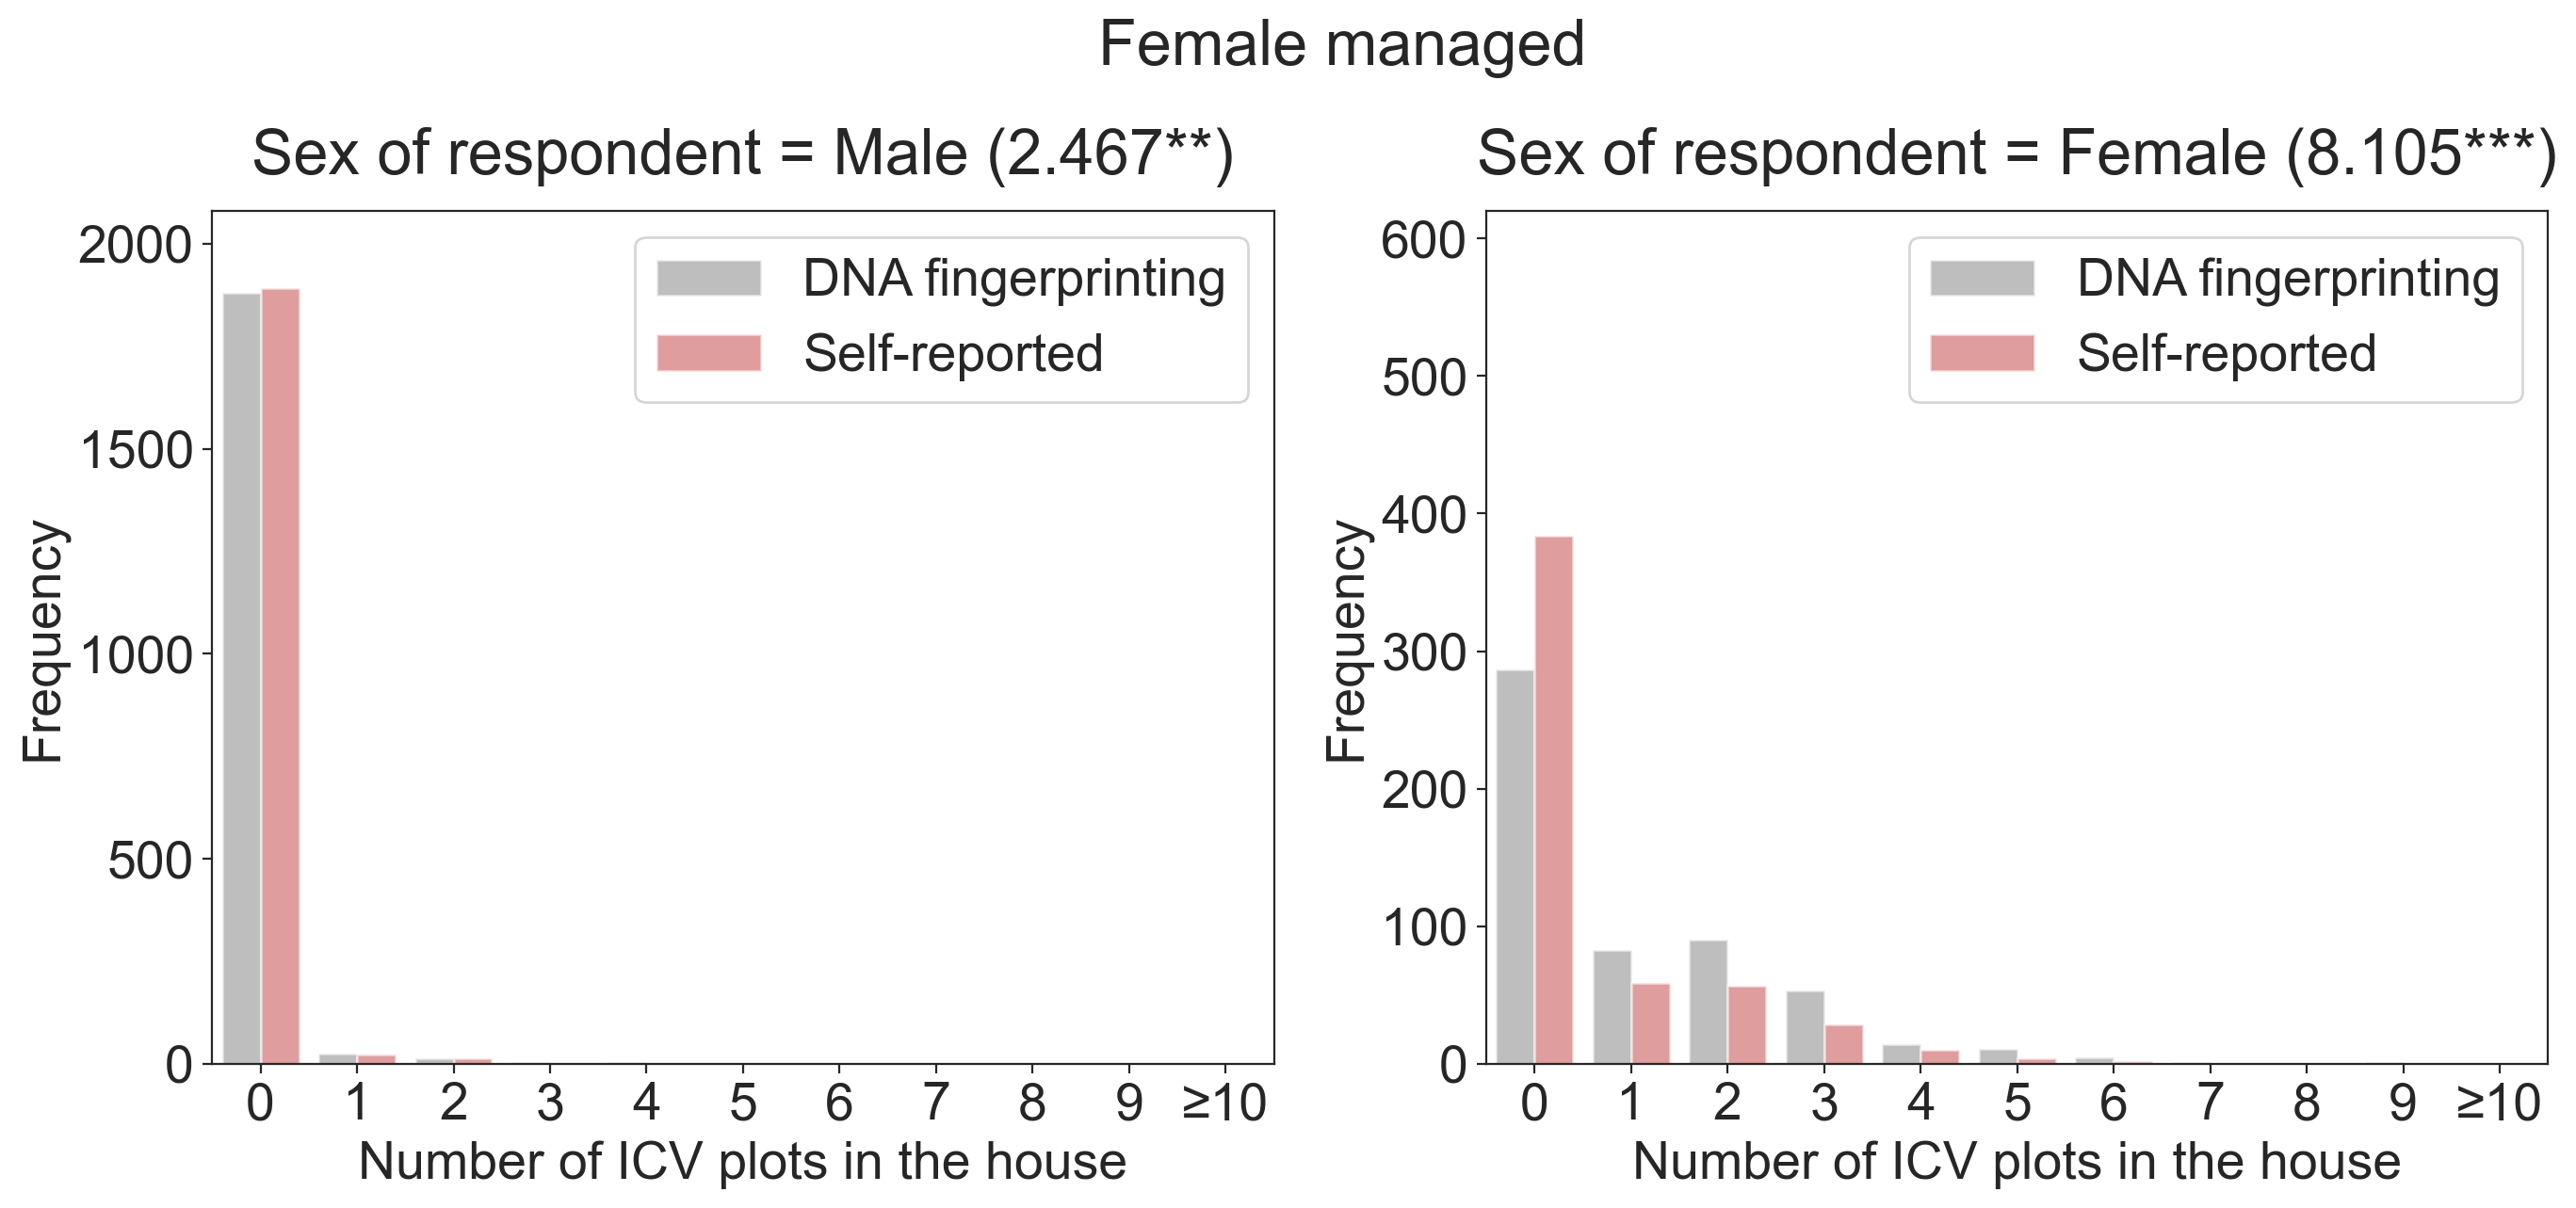

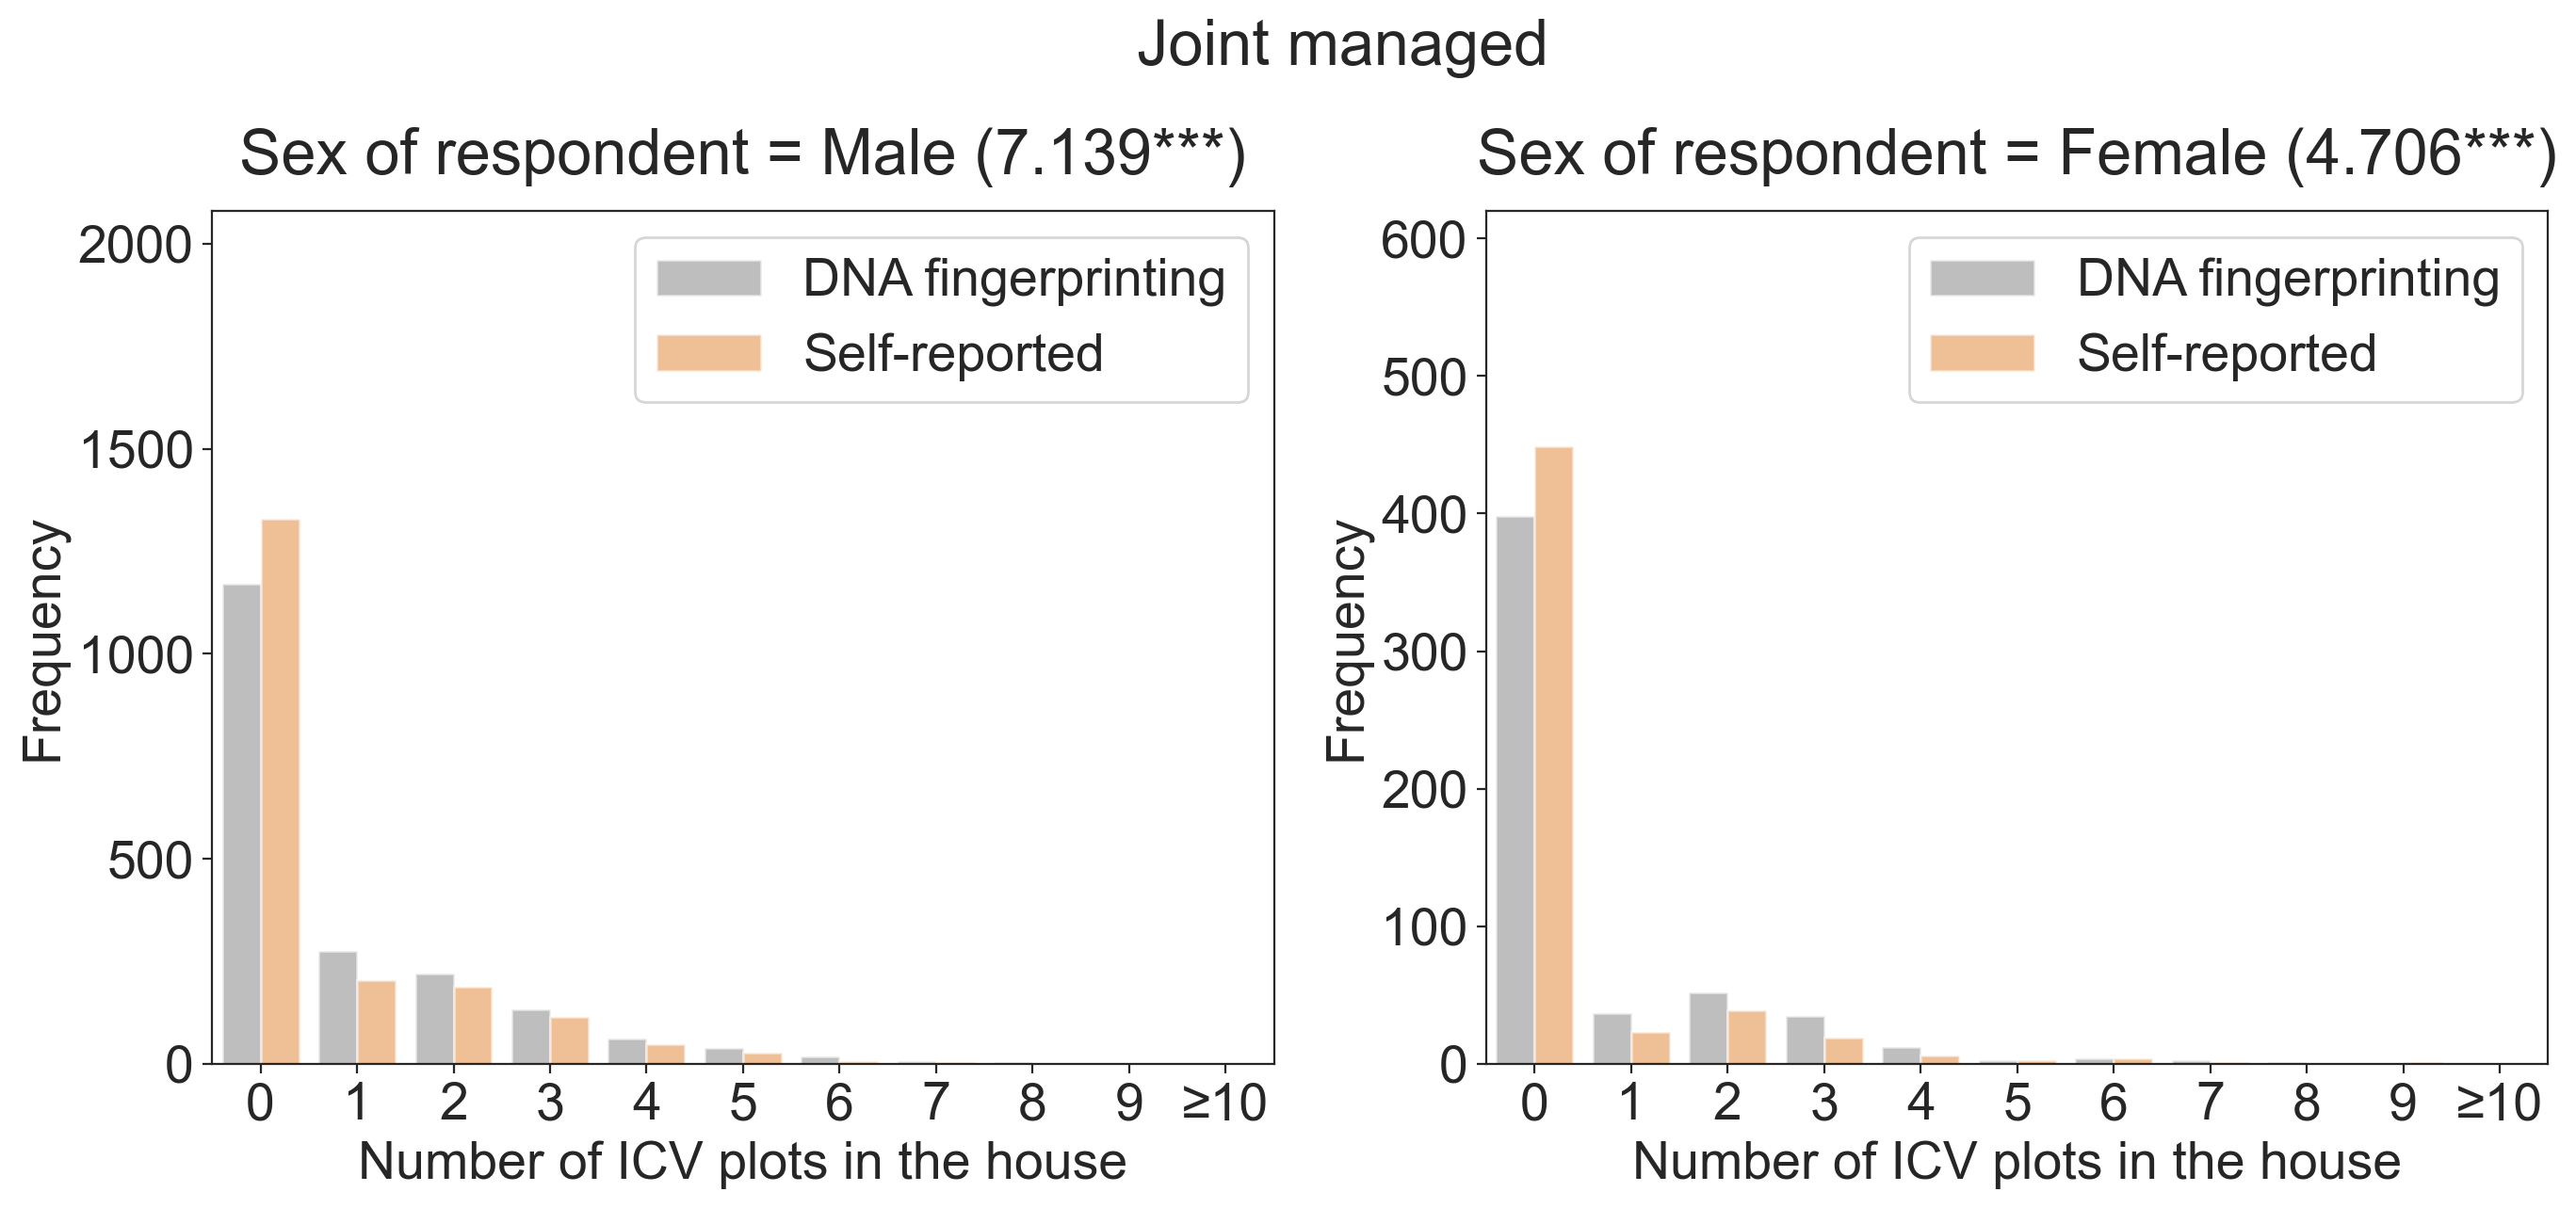

In [30]:
var = 'Total ICV Joint'
# plt.rcParams.update({'font.size': 16})

for _, color in zip(['Male', 'Female', 'Joint'], ['C0', 'C3', 'C1']):
    var = 'Household_ICV_' + _

    fig1, ax1 = plt.subplots(1, 2, figsize=(16,6), dpi=200)
    df_CMS_HH_DNA_male = summary_cms_byplot[summary_cms_byplot['A02_Sex'] == 'Male']
    df_CMS_HH_DNA_female = summary_cms_byplot[summary_cms_byplot['A02_Sex'] == 'Female']

    sns.barplot(df_CMS_HH_DNA_male[(df_CMS_HH_DNA_male['variable'] == var)], x='level',  y='count',
                    ax = ax1[0], 
                    hue="source", errorbar=None, palette=["C7", color], alpha=0.5)
    
    sns.barplot(df_CMS_HH_DNA_female[(df_CMS_HH_DNA_female['variable'] == var)], x='level',  y='count',
                    ax = ax1[1], 
                    hue="source", errorbar=None, palette=["C7", color], alpha=0.5)

    ax1[0].set_xlabel('Total ICV')
    ax1[1].set_xlabel('Total ICV')
    # fig1.suptitle(f'{_} managed')

    df_CMS_HH_DNA_byplot_male = df_CMS_HH_DNA_byplot[df_CMS_HH_DNA_byplot['A02_Sex'] == 'Male'][
        [f'Total ICV {_} - DNA',  f'Total ICV {_} - Survey', 'A02_Sex']]
    
    df_CMS_HH_DNA_byplot_female = df_CMS_HH_DNA_byplot[df_CMS_HH_DNA_byplot['A02_Sex'] == 'Female'][
        [f'Total ICV {_} - DNA',  f'Total ICV {_} - Survey', 'A02_Sex']]
    
    ttest_HM = ttest_rel(df_CMS_HH_DNA_byplot_male[f'Total ICV {_} - DNA'], 
                         df_CMS_HH_DNA_byplot_male[f'Total ICV {_} - Survey'], nan_policy='omit')
    ttest_HF = ttest_rel(df_CMS_HH_DNA_byplot_female[f'Total ICV {_} - DNA'], 
                         df_CMS_HH_DNA_byplot_female[f'Total ICV {_} - Survey'], nan_policy='omit')
    print(ttest_HM)
    print(['DNA fingerprinting vs Self-reported', convert_pvalue(ttest_HM[0], ttest_HM[1])])
    print(['DNA fingerprinting vs Self-reported', convert_pvalue(ttest_HF[0], ttest_HF[1])])
    
    ax1[0].set_ylabel('Frequency')
    ax1[0].set_xlabel('Y/N ICV' if var == 'planted' else 'Total ICV')

    ax1[1].set_ylabel('Frequency')
    ax1[1].set_xlabel('Y/N ICV' if var == 'planted' else 'Total ICV')

    ax1[0].set_title(f'Sex of respondent = Male ({convert_pvalue(ttest_HM[0], ttest_HM[1])})',  y=1.025)
    ax1[1].set_title(f'Sex of respondent = Female ({convert_pvalue(ttest_HF[0], ttest_HF[1])})', y=1.025)
    ax1[0].legend(loc=1)
    ax1[1].legend(loc=1)

    ax1[0].legend(labels=['DNA fingerprinting', 'Self-reported'])
    ax1[1].legend(labels=['DNA fingerprinting', 'Self-reported'])
    ax1[0].set_ylim(0, 2080)
    ax1[1].set_ylim(0, 620)
    ax1[0].set_yticks([i for i in range(0, 2010, 500)])
    ax1[1].set_yticks([i for i in range(0, 610, 100)])
    ax1[0].set_xlabel('Number of ICV plots in the house' )
    ax1[1].set_xlabel('Number of ICV plots in the house')
    
        
    fig1.suptitle(f'{_} managed', y=1.05)
    fig1.savefig(f"../Manuscript/Figures/Figure_5_{_}_managed.pdf", dpi=600, bbox_inches='tight' )


In [18]:
import numpy as np
from scipy import stats

# Your two samples
x1 = np.array([1163, 326, 240, 120, 42, 18, 13, 6, 0, 1, 1])
x2 = np.array([1272, 266, 212, 114, 35, 17, 7, 5, 0, 1, 1])

# Perform independent-samples t-test
t_stat, p_val = stats.ttest_ind(x1, x2, equal_var=False)  # Welch’s t-test (safer when variances differ)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_val:.3f}")

T-statistic: 0.000
P-value: 1.000


In [19]:
# fig1, ax1 = plt.subplots(1, 3, figsize=(24,6), dpi=200)

# for index, _ in enumerate(['Male', 'Female', 'Joint']):
#     # fig1, ax1 = plt.subplots(1, 3, figsize=(21,5), dpi=200)

#     var = f'Total ICV {_}'
#     c = {'Male': 'C0', 'Female': 'C3', 'Joint': 'C1'}
#     sns.kdeplot(df_CMS_HH_DNA[var + " - DNA"], ax = ax1[index],  color="C7", label ="DNA fingerprinting")
#     sns.kdeplot(df_CMS_HH_DNA[var + " - Survey"], ax = ax1[index], color=c[_], label ="Self-reported")
#     ttest = ttest_rel(df_CMS_HH_DNA[f'{var} - DNA'], df_CMS_HH_DNA[f'{var} - Survey'], nan_policy='omit')
    
#     data = []
#     print('DNA fingerprinting vs Self-reported', convert_pvalue(ttest[0], ttest[1]))
#     # df_ttest = pd.DataFrame(data, columns = ['Comparison', 'T-test'])
#     # ax1.table(cellText=df_ttest.values, colLabels=df_ttest.columns, 
#     #           cellLoc='left', colWidths=[0.8, 0.3], bbox = (0.4, 0.05, 0.55, 0.15), loc='lower right', zorder=10)


#     ax1[index].set_ylabel('Density')
#     ax1[index].set_xlabel('Y/N ICV' if var == 'planted' else 'Total ICV')
#     #ax1[index].set_xlim(-1, 6)
#     ax1[index].set_title(f'{_} managed ({convert_pvalue(ttest[0], ttest[1])})', y=1.05)
#     ax1[index].legend(loc=1)
    
#     ax1[index].set_ylim(0, 2)
#     ax1[index].set_xlim(-3, 15)
#     ax1[index].set_yticks([0, 0.5, 1, 1.5, 2])


# fig1.savefig(f"../Manuscript/Figures/Figure_5.pdf", dpi=600, bbox_inches='tight' )